Fase 1: Análise Exploratória de Dados (EDA) <br><br><br>


  Fase 1: 

* Descritiva e estatística


In [20]:
#Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Carregamento dos dados e visualizar as primeiras linhas


In [21]:
df = pd.read_csv("credit_risk_dataset.csv")

print("Primeiras 5 linhas da base de dados:")
df.head()

Primeiras 5 linhas da base de dados:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Dimensões da base

In [22]:
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")

Número de linhas: 32581
Número de colunas: 12


Informações gerais

In [23]:
print("Informações gerais da base:")
df.info()

Informações gerais da base:
<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


Após executar o método df.info(), conclui-se:
o DataFrame — tem 32.581 linhas (registros).
Cada linha representa uma pessoa e um pedido de empréstimo.

Classificação das colunas do DataFrame

* Colunas numéricas

person_age (int64) — idade da pessoa.

person_income (int64) — renda anual.

person_emp_length (float64) — anos de emprego; possui 895 valores ausentes.

loan_amnt (int64) — valor do empréstimo.

loan_int_rate (float64) — taxa de juros; possui 3.116 valores ausentes.

loan_status (int64) — status do empréstimo (codificado).

loan_percent_income (float64) — porcentagem da renda comprometida.

cb_person_cred_hist_length (int64) — anos de histórico de crédito.

* Colunas categóricas

person_home_ownership (object) — tipo de moradia.

loan_intent (object) — intenção do empréstimo.

loan_grade (object) — classificação do empréstimo.

cb_person_default_on_file (object) — registro de default (Y/N).

* Valores ausentes

“non-null” = valores presentes |
“entries” = total de linhas

Se non-null < entries, então existem valores faltantes.

person_emp_length → faltam 895 valores

loan_int_rate → faltam 3116 valores

Para melhor conduzir as explicações deste código, crio um dicionário:

In [24]:
dicionario_traducao = {
    'person_age': 'idade_pessoa',
    'person_income': 'renda_pessoa',
    'person_home_ownership': 'tipo_residencia',
    'person_emp_length': 'tempo_emprego',
    'loan_intent': 'finalidade_emprestimo',
    'loan_grade': 'classificacao_emprestimo',
    'loan_amnt': 'valor_emprestimo',
    'loan_int_rate': 'taxa_juros_emprestimo',
    'loan_status': 'status_emprestimo',
    'loan_percent_income': 'percentual_renda_comprometida',
    'cb_person_default_on_file': 'historico_inadimplencia',
    'cb_person_cred_hist_length': 'tempo_historico_credito'
}
df = df.rename(columns=dicionario_traducao)

Sumário Estatístico Descritivo

In [25]:
print("Resumo estatístico das variáveis numéricas:")
df.describe()

Resumo estatístico das variáveis numéricas:


,idade_pessoa,renda_pessoa,tempo_emprego,valor_emprestimo,taxa_juros_emprestimo,status_emprestimo,percentual_renda_comprometida,tempo_historico_credito
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


As métricas que o Pandas mostra no resumo estatístico:

count → contagem de valores não nulos na coluna.

mean → média

std → desvio padrão: o quanto os dados “espalham” - indica o quanto os valores variam em relação à média.

min → mínimo: menor valor encontrado na coluna.

25% → 1º quartil (Q1): 25% dos valores são menores ou iguais a esse número.

50% → mediana (Q2): metade dos valores está abaixo e metade acima.

75% → 3º quartil (Q3): 75% dos valores são menores ou iguais a esse número.

max → máximo: maior valor encontrado na coluna.


Fase 1: 

* Visual - histograma de distribuição de idades/valores

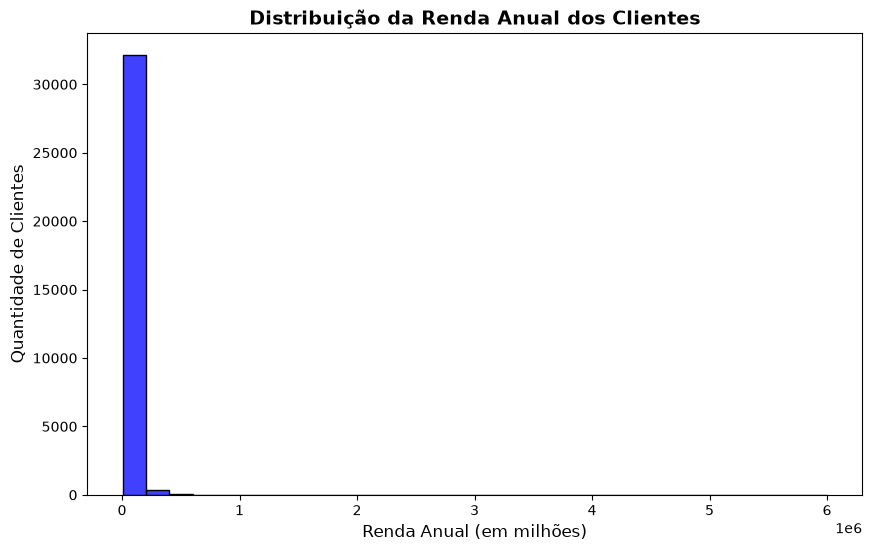

In [26]:
plt.figure(figsize=(10,6))

# Criar o histograma
#sns.histplot(data=df, x="renda_pessoa", bins=30, color="skyblue")
sns.histplot(data=df, x="renda_pessoa", bins=30, color="blue", edgecolor="black")

# Títulos e rótulos
plt.title("Distribuição da Renda Anual dos Clientes", fontsize=14, fontweight="bold")
plt.xlabel("Renda Anual (em milhões)", fontsize=12)
plt.ylabel("Quantidade de Clientes", fontsize=12)

# gráfico
plt.show()

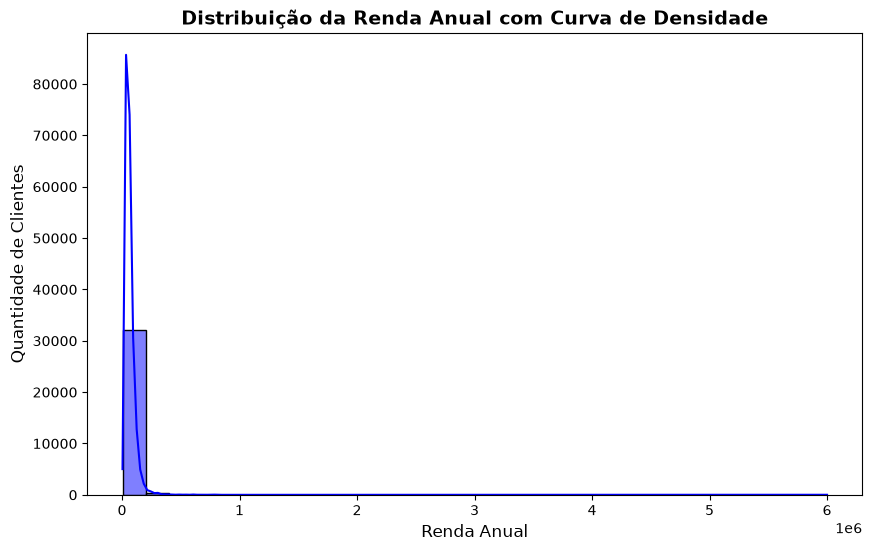

In [27]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="renda_pessoa", bins=30, kde=True,
             color="blue", edgecolor="black")
plt.title("Distribuição da Renda Anual com Curva de Densidade", fontsize=14, fontweight="bold")
plt.xlabel("Renda Anual", fontsize=12)
plt.ylabel("Quantidade de Clientes", fontsize=12)
plt.show()

Verificado que este gráfico precisa de ajustes para melhor análise, sendo assim, redefini as escalas como explicado:

Os quartis mostram que 25% dos clientes têm renda até cerca de R$ 38.500, indicando a faixa de menor renda.
A mediana, em torno de R$ 55.000, revela a renda típica da base. Os 75% dos clientes ganham até aproximadamente R$ 79.200, mostrando que rendas mais altas são menos frequentes. Os valores acima disso representam a cauda da distribuição, composta por poucos clientes com renda muito elevada.
Decidi criar dois conjuntos, pois o Histograma é uma ferramenta poderosa visualmente.

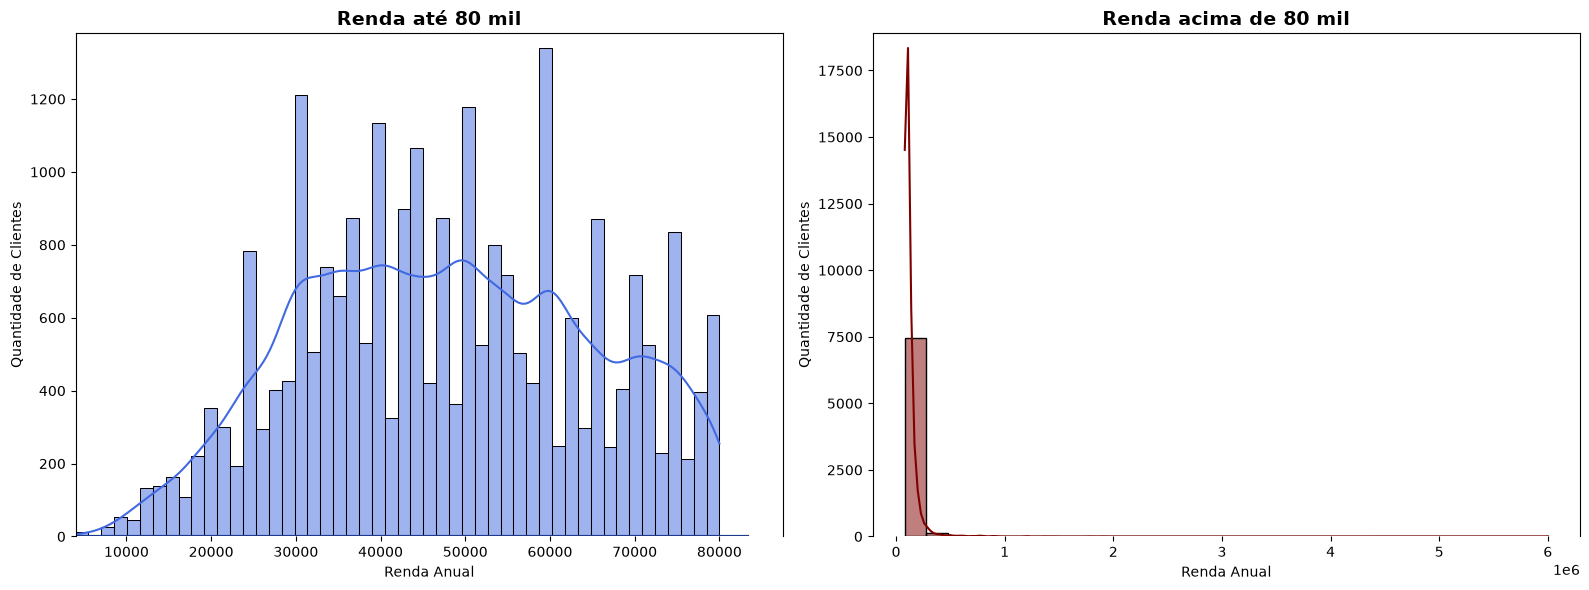

In [28]:
# Criar dois conjuntos
df_ate_80k = df[df['renda_pessoa'] <= 80000]
df_acima_80k = df[df['renda_pessoa'] > 80000]

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Histograma até 80 mil 
sns.histplot(
    data=df_ate_80k,
    x="renda_pessoa",
    bins=50, kde=True,
    color="#4169E1",  
    edgecolor="black",
    ax=axes[0]
)
sns.kdeplot(
    df_ate_80k['renda_pessoa'],
    color="#1E3A8A",
    bw_adjust=0.5,
    ax=axes[0]
)
axes[0].set_title("Renda até 80 mil", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Renda Anual")
axes[0].set_ylabel("Quantidade de Clientes")
axes[0].spines['bottom'].set_color('none')
axes[0].margins(y=0.03)
axes[0].set_xlim(left=df['renda_pessoa'].min())

# Histograma acima de 80 mil 
sns.histplot(
    data=df_acima_80k,
    x="renda_pessoa",
    bins=30, kde=True,
    color="#800000",  
    edgecolor="black",
    ax=axes[1]
)
sns.kdeplot(
    df_ate_80k['renda_pessoa'],
    color="#1E3A8A",
    bw_adjust=0.5,
    ax=axes[0]
)
axes[1].set_title("Renda acima de 80 mil", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Renda Anual")
axes[1].set_ylabel("Quantidade de Clientes")
axes[1].spines['bottom'].set_color('none')
axes[1].margins(y=0.03)

plt.tight_layout()
plt.show()

A linha KDE representa a estimativa contínua da densidade dos dados, a tendência geral da distribuição de renda.
No gráfico até 80 mil, a curva evidencia maior concentração entre 30 000 e 60 000, indicando que essa faixa reúne a maioria dos clientes. Já no gráfico acima de 80 mil, a curva despenca rapidamente, revelando que rendas elevadas são raras e formam uma cauda longa à direita.
essa visualização complementa o histograma ao destacar a forma **assimétrica** da distribuição e a presença de poucos valores extremos.

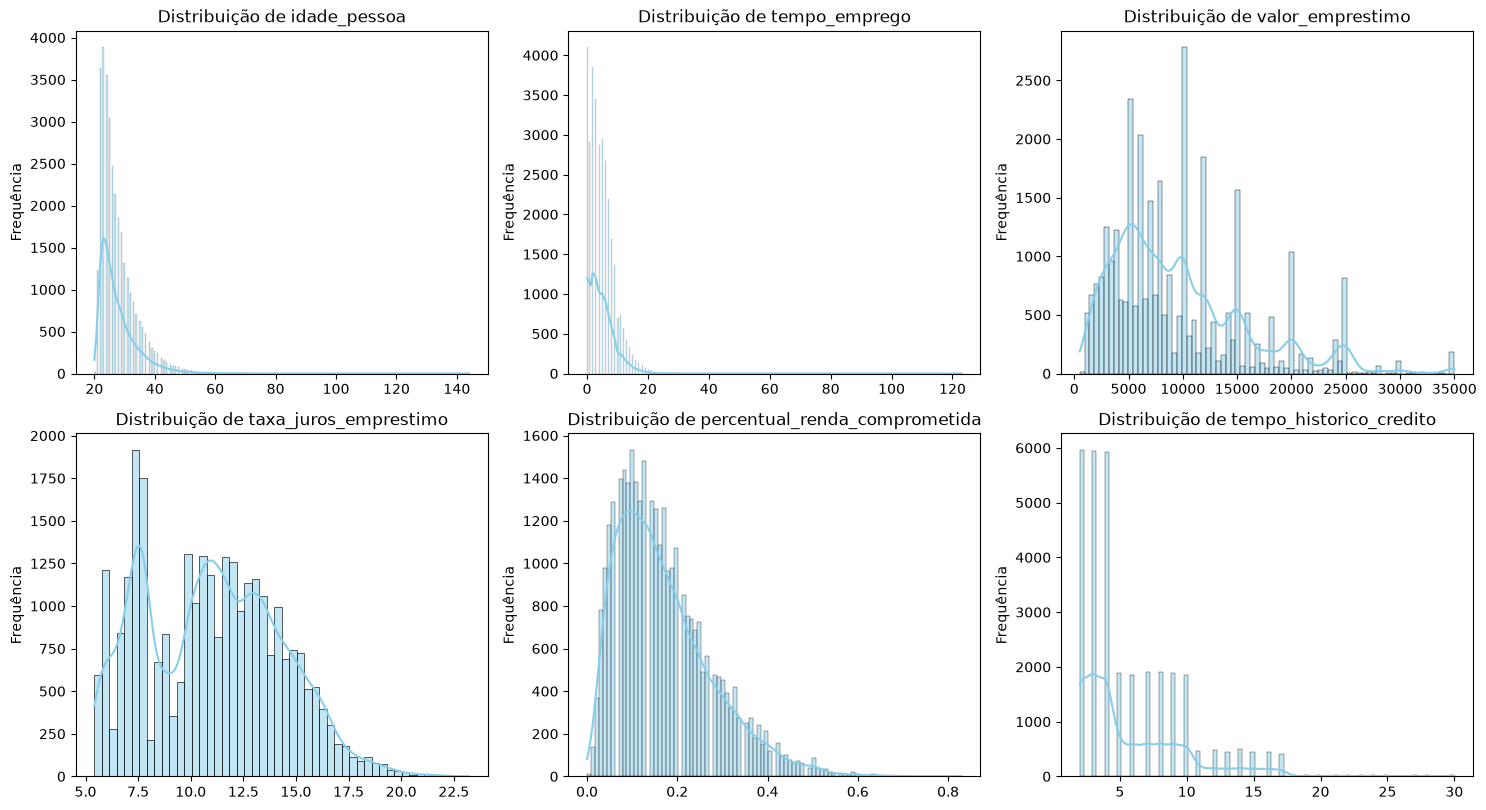

In [29]:
# Lista das demais colunas numéricas 
# 'status_emprestimo' é alvo
colunas_numericas = [
    'idade_pessoa', 'tempo_emprego', 
    'valor_emprestimo', 'taxa_juros_emprestimo', 
    'percentual_renda_comprometida', 'tempo_historico_credito'
]

# Configura o layout dos gráficos (ajuste o número de linhas/colunas conforme necessário)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten() # Achata a matriz de eixos para facilitar o loop

for i, col in enumerate(colunas_numericas):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribuição de {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequência')

# Remove eixos vazios caso sobrem espaços
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Análise dos demais Histogramas 

Os gráficos de distribuição revelaram pontos importantes:

* O histograma de `idade_pessoa` mostra dados até 140 anos. Isso confirma a presença de **outliers** (erros de registro) que precisam ser tratados na Fase 2 para não enviesar o modelo.
* O gráfico de `valor_emprestimo` mostra uma preferência por valores arredondados, sugerindo um comportamento padronizado do mercado.
* A `tempo_historico_credito` mostra uma concentração em valores baixos, indicando que a base é composta majoritariamente por clientes com histórico financeiro recente.


  Fase 1: 

* Visual - gráfico de barras provando o desbalanceamento da variável alvo: (alvo: loan_status = 1) ou se pagará o empréstimo em dia (alvo: loan_status = 0), ou seja, 'status_emprestimo'.

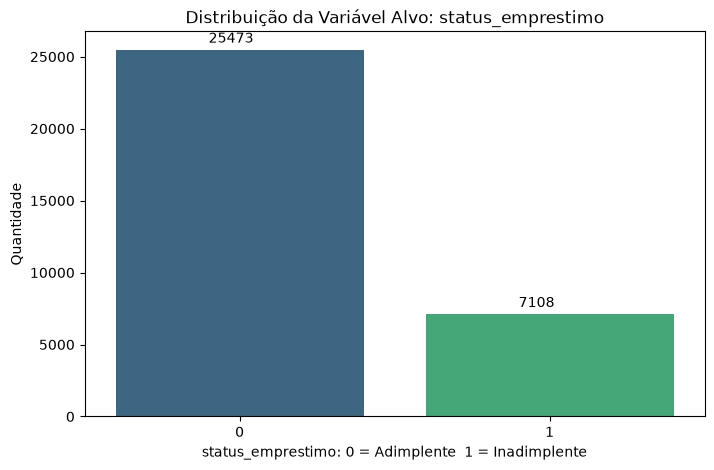

In [30]:
plt.figure(figsize=(8,5))
ax = sns.countplot(
    x='status_emprestimo',
    data=df,
    hue='status_emprestimo',
    palette='viridis',
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 500))

plt.title('Distribuição da Variável Alvo: status_emprestimo')
plt.xlabel('status_emprestimo: 0 = Adimplente  1 = Inadimplente')
plt.ylabel('Quantidade')
plt.show()

O gráfico de barras mostra que a **variável alvo é desbalanceada, com a classe 0 representando a maior parte dos registros**. O modelo, se treinado sem correções, tenderá a prever a classe predominante, resultando em métricas artificialmente altas e baixa capacidade de identificar corretamente a classe minoritária.

  Fase 1: 

* Visual - mapa de calor de correlação de Pearson

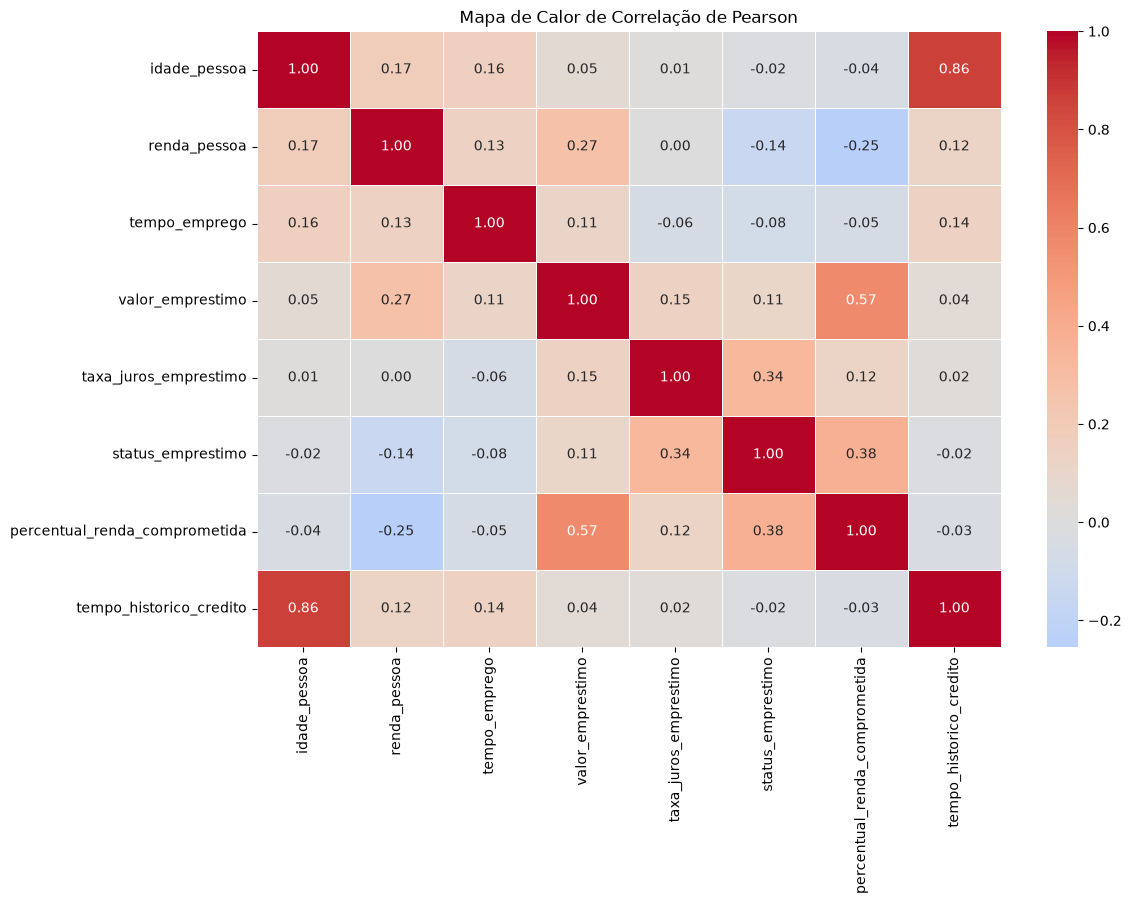

In [31]:
# Calcula a matriz de correlação
corr = df.corr(numeric_only=True)

# Define o tamanho e estilo do gráfico
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title('Mapa de Calor de Correlação de Pearson')
plt.show()

**Interpretações do Gráfico acima**:

1.Relações entre variáveis e alvo (status_emprestimo)
percentual_renda_comprometida → correlação positiva com inadimplência (Essa variável mede quanto do salário a pessoa compromete com o empréstimo.)
Quanto maior o percentual da renda comprometida, maior a chance de inadimplência. 

taxa_juros_emprestimo → correlação positiva com inadimplência. 

valor_emprestimo → correlação moderada com inadimplência Quanto maior o valor do empréstimo, maior o risco. 

renda_pessoa → correlação negativa com inadimplência Renda maior → menor risco. Clientes com renda mais alta têm mais capacidade de pagar.

idade_pessoa → correlação fraca Idade não é um grande preditor isolado.

tempo_emprego → correlação fraca/moderada Tempo de emprego maior tende a reduzir risco. Estabilidade profissional diminui inadimplência.

tempo_historico_credito → correlação fraca Histórico de crédito mais longo geralmente indica maturidade financeira, sozinho não é tão forte quanto renda ou percentual comprometido.

2.Relações entre variáveis (multicolinearidade)

valor_emprestimo vs percentual_renda_comprometida → correlação forte Empréstimos maiores comprometem maior parte da renda.
Isso significa: Essas duas variáveis carregam informação parecida. O modelo pode ficar redundante se ambas forem usadas sem cuidado.

renda_pessoa vs percentual_renda_comprometida → correlação negativa forte. Quanto maior a renda, menor o percentual comprometido.

O mapa de calor revela que as variáveis Percentual da Renda Comprometida, Taxa de Juros do Empréstimo e Valor do Empréstimo apresentam correlação positiva com o Status do Empréstimo, indicando que clientes com maior comprometimento de renda, juros mais altos ou empréstimos maiores tendem a ser mais inadimplentes.
Renda do Cliente apresenta correlação negativa com o alvo, sugerindo que rendas maiores reduzem o risco de calote.
Observa-se multicolinearidade entre as variáveis Valor do Empréstimo e Percentual da Renda Comprometida, que apresentam correlação elevada entre si. Isso indica que ambas carregam informação semelhante, o que pode gerar redundância e instabilidade em modelos baseados em distância, como o KNN.
Para modelos de Árvore de Decisão, essa multicolinearidade não representa risco, pois árvores são robustas a variáveis correlacionadas.

# Tomada de Decisão: Estratégia para a Preparação dos Dados

A análise estatística e os gráficos iniciais revelaram pontos críticos na nossa base de risco de crédito.

* Tratamento e limpeza (Fase 2):** Encontrei valores impossíveis na base, como idade de 144 anos e tempo de emprego de 123 anos, linhas com valores em branco (nulos). Corrigir isso é impoprtante, porque o modelo **KNN**, calcula a distância entre os pontos e é extremamente sensível a esses erros (outliers). Já a nossa **Árvore de Decisão** é bem mais resistente a esses valores distorcidos.
* Feature Engineering (Fase 3):** Criar a coluna calculada `comprometimento_renda`, que vai mostrar em formato de porcentagem o quanto do salário do cliente a parcela ocupa.
* Separação, Balanceamento e Escalonamento Seguro (Fase 4):** O gráfico de barras provou que a nossa variável alvo (`status_emprestimo`) é muito desbalanceada, tendo muito mais registros de pagamentos em dia do que de calotes. Para o modelo não ficar viciado em responder apenas que "o cliente vai pagar", balancear as classes no treino. Aplicar a padronização de escala (`StandardScaler`) apenas para o **KNN**, deixando a **Árvore de Decisão** sem esse ajuste, já que ela trabalha fazendo cortes lógicos e não depende do tamanho ou da escala dos números.


***

Fase 2: Tratamento e Limpeza (Data Prep)     
<br><br><br><br><br><br>
Fase 2:

* Duplicadas

In [32]:
print("Quantidade de linhas duplicadas:")

duplicadas = df.duplicated().sum()

print(duplicadas)

Quantidade de linhas duplicadas:
165


Remoção das duplicadas e verificação de linhas atuais.

In [33]:
duplicadas_antes = df.duplicated().sum()
print(f"Linhas duplicadas antes da remoção: {duplicadas_antes}")

# Remover duplicadas
df = df.drop_duplicates()

# Verificar novamente
duplicadas_depois = df.duplicated().sum()
total_linhas = df.shape[0]

print(f"Linhas duplicadas após a remoção: {duplicadas_depois}")
print(f"Total de linhas restantes no dataframe: {total_linhas}")

Linhas duplicadas antes da remoção: 165
Linhas duplicadas após a remoção: 0
Total de linhas restantes no dataframe: 32416


Realizada a verificação de duplicadas utilizando o método duplicated().
Antes da limpeza, a base apresentava 165 registros duplicados.
Após aplicar drop_duplicates(), o número de duplicadas foi reduzido para 0, garantindo que cada linha represente um cliente único.
O dataframe final passou a conter 32416 linhas válidas.

Fase 2

* Valores Nulos: Identifique as colunas com dados ausentes. É obrigatório justificar textualmente a escolha da técnica de imputação: usou a Média (indicada para distribuições normais/simétricas) ou a Mediana (indicada para mitigar o impacto de outliers)?

# Tratamento de Valores Nulos 

Ao executar o comando `df.info()`, identifiquei que as colunas `tempo_emprego` (person_emp_length) e `taxa_juros_emprestimo` (loan_int_rate) possuem dados ausentes (valores nulos).

A técnica escolhida para preencher esses dados ausentes será a **Imputação pela Mediana**. 
Justifico essa escolha porque, como vimos na análise exploratória, a base apresenta variáveis com distribuição assimétrica e indícios de valores extremos. Além disso, a coluna tempo_emprego apresenta um valor máximo muito superior ao terceiro quartil, indicando possível influência de outliers. Conforme pode ser observado na tabela a seguir, utilizo da mediana para imputação dos valores ausentes, por ser uma medida de tendência central mais robusta à presença de valores extremos, *outliers*.


In [34]:
estatisticas = df[['tempo_emprego', 'taxa_juros_emprestimo']].describe().T

estatisticas['Valores Nulos'] = (
    df[['tempo_emprego', 'taxa_juros_emprestimo']]
    .isnull()
    .sum()
)

estatisticas

,count,mean,std,min,25%,50%,75%,max,Valores Nulos
tempo_emprego,31529.0,4.790510,4.14549,0.00,2.0,4.00,7.00,123.00,887
taxa_juros_emprestimo,29321.0,11.017265,3.24168,5.42,7.9,10.99,13.47,23.22,3095


In [35]:
# Verificando a quantidade de valores nulos antes
print("Valores nulos antes da imputação:")
print(df[['tempo_emprego', 'taxa_juros_emprestimo']].isnull().sum())

# Imputação utilizando a mediana, por ser mais robusta à presença de valores extremos (outliers)
# e adequada para distribuições assimétricas.

df['tempo_emprego'] = df['tempo_emprego'].fillna(df['tempo_emprego'].median())
df['taxa_juros_emprestimo'] = df['taxa_juros_emprestimo'].fillna(df['taxa_juros_emprestimo'].median())

# Verificando a quantidade de valores nulos após a imputação
print("\nValores nulos após a imputação (O resultado deve ser 0):")
print(df[['tempo_emprego', 'taxa_juros_emprestimo']].isnull().sum())

Valores nulos antes da imputação:
tempo_emprego             887
taxa_juros_emprestimo    3095
dtype: int64

Valores nulos após a imputação (O resultado deve ser 0):
tempo_emprego            0
taxa_juros_emprestimo    0
dtype: int64


Fase 2

* Tratamento de Outliers: Identificar a presença de valores discrepantes na base (ex: via boxplots). O aluno deve tomar uma decisão fundamentada de tratamento (remoção, clipping ou manutenção). Nota pedagógica: Avalie o impacto disso nos modelos, lembrando que o KNN é extremamente sensível a outliers (muda as distâncias euclidianas), enquanto a Árvore de Decisão é robusta a eles. 

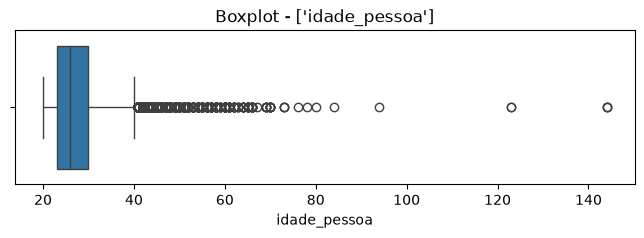

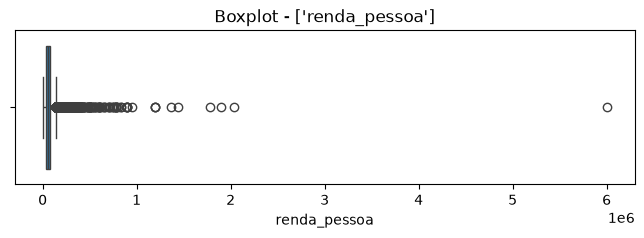

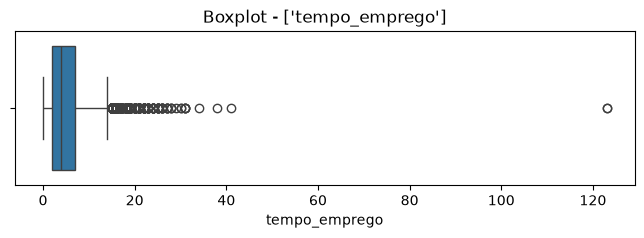

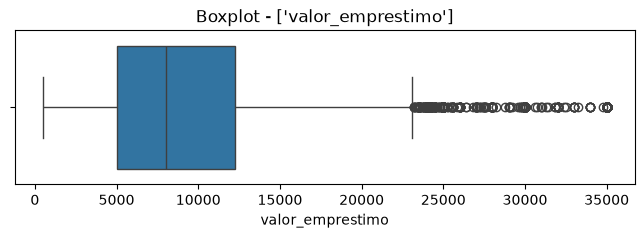

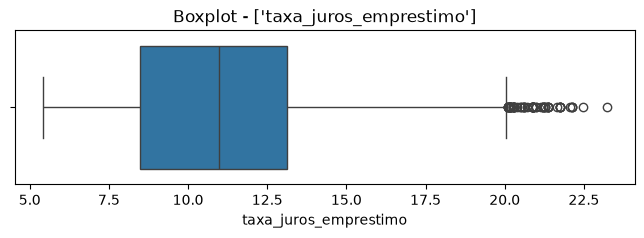

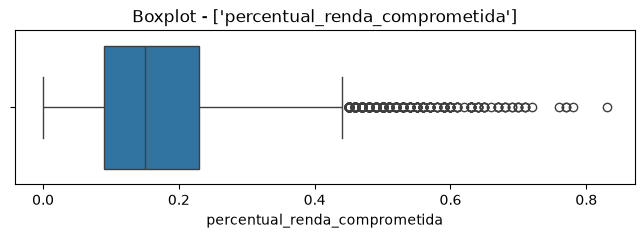

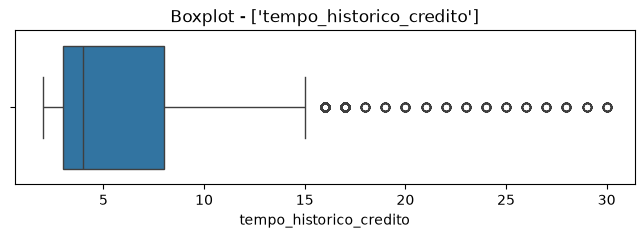

In [36]:
# Iniciei com a plotagem para os boxplot

colunas_numericas = [
    'idade_pessoa',
    'renda_pessoa',
    'tempo_emprego',
    'valor_emprestimo',
    'taxa_juros_emprestimo',
    'percentual_renda_comprometida',
    'tempo_historico_credito'
]

for coluna in colunas_numericas:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=df[coluna])

    plt.title(f'Boxplot - {[coluna]}')

    plt.show()

Busquei um gráfico para melhor analisar e entender esses dados para a aplicação futura dos modelos.
O Uso do Plotly para Análise Visual para melhor entender informações discrepantes (outliers).

* **Visualização Interativa:** A interatividade do Plotly facilitou a inspeção individual de cada ponto que ultrapassa os limites do boxplot, confirmando que a maioria dos valores extremos na base de `renda_pessoa` não são erros de digitação, mas sim clientes com rendas muito acima da média do grupo.


In [37]:
import plotly.express as px

fig_idade = px.box(
    df, 
    x="idade_pessoa", 
    title="Auditoria Interativa: Idade da Pessoa (Passe o mouse nas bolinhas)",
    points="outliers"
)
fig_idade.update_traces(marker_color='skyblue')
fig_idade.show()

In [38]:
import plotly.express as px

fig_emprego = px.box(
    df, 
    x="tempo_emprego", 
    title="Auditoria Interativa: Tempo de Emprego (Passe o mouse nas bolinhas)",
    points="outliers"
)
fig_emprego.update_traces(marker_color='salmon')
fig_emprego.show()

In [39]:
import plotly.express as px

fig_renda = px.box(
    df, 
    x="renda_pessoa", 
    title="Auditoria Interativa: Renda Anual (Passe o mouse nas bolinhas)",
    points="outliers"
)
fig_renda.update_traces(marker_color='lightgreen')
fig_renda.show()

In [40]:
import plotly.express as px

fig_valor = px.box(
    df, 
    x="valor_emprestimo", 
    title="Auditoria Interativa: Valor do Empréstimo Solicitado",
    points="outliers"
)
fig_valor.update_traces(marker_color='gold')
fig_valor.show()

In [41]:
import plotly.express as px

fig_juros = px.box(
    df, 
    x="taxa_juros_emprestimo", 
    title="Auditoria Interativa: Taxa de Juros do Empréstimo",
    points="outliers"
)
fig_juros.update_traces(marker_color='orchid')
fig_juros.show()

In [42]:
import plotly.express as px

fig_comprometimento = px.box(
    df, 
    x="percentual_renda_comprometida", 
    title="Auditoria Interativa: Percentual da Renda Comprometida",
    points="outliers"
)
fig_comprometimento.update_traces(marker_color='aquamarine')
fig_comprometimento.show()


In [43]:
import plotly.express as px

fig_historico = px.box(
    df, 
    x="tempo_historico_credito", 
    title="Auditoria Interativa: Tempo de Histórico de Crédito (Passe o mouse)",
    points="outliers"
)
fig_historico.update_traces(marker_color='orange')
fig_historico.show()

# Avaliação do Impacto dos Outliers nos Modelos Propostos

Após a análise visual realizada por meio do **Boxplot**, foram identificados valores extremos que podem impactar o desempenho dos modelos propostos. Entre os outliers encontrados, destacam-se dois registros considerados inconsistentes do ponto de vista biológico e profissional: um registro com **144 anos de idade** e outro com **123 anos de tempo de emprego**.

## Decisão Metodológica: Remoção (Drop)

Optei pela **remoção dessas duas observações da base de dados**, pois representam inconsistências impossíveis de serem corrigidas ou interpretadas como cenários reais. Valores dessa natureza podem prejudicar o aprendizado dos algoritmos, principalmente aqueles baseados em cálculo de distância.

Como a base possui mais de **32.000 registros**, a exclusão dessas duas linhas representa uma alteração estatisticamente irrelevante no volume total dos dados, porém contribui para melhorar a qualidade da modelagem, evitando que informações inválidas influenciem os resultados dos modelos.

Os demais outliers identificados, como valores elevados de renda (até aproximadamente **6 milhões**) e taxas de juros de até **23%**, foram **mantidos**, pois podem representar situações reais do mercado financeiro. Esses registros podem conter informações relevantes para a identificação de padrões relacionados ao risco de crédito e, portanto, não devem ser removidos apenas por apresentarem valores elevados.

## Impacto nos Modelos Propostos

### 1. Árvore de Decisão

A presença de outliers possui menor impacto na **Árvore de Decisão**, pois esse algoritmo realiza previsões através de regras baseadas em divisões dos dados, como valores maiores ou menores que determinados limites.

Diferentemente de algoritmos baseados em distância, a Árvore de Decisão não calcula proximidade entre registros e, por isso, valores extremos não alteram diretamente a escala das variáveis utilizadas pelo modelo.

Dessa forma, os outliers considerados possíveis, como rendas elevadas e taxas de juros maiores, foram mantidos para que o algoritmo possa aprender padrões reais presentes no mercado de crédito.

### 2. KNN (K-Nearest Neighbors)

O impacto dos outliers é mais relevante no algoritmo **KNN (K-Nearest Neighbors)**, pois seu funcionamento depende do cálculo de distância entre os registros, utilizando normalmente a **distância euclidiana** para identificar os vizinhos mais próximos.

Valores extremos podem aumentar artificialmente a distância entre observações e fazer com que determinadas variáveis tenham maior influência no cálculo, prejudicando a identificação dos registros realmente semelhantes.

Por esse motivo, foram removidos os outliers considerados erros de dados, como a idade de **144 anos** e o tempo de emprego de **123 anos**. Já os demais valores extremos, que possuem possibilidade de ocorrência real, serão mantidos e terão seu impacto tratado posteriormente na **Fase 4**, através da aplicação de técnicas de escalonamento, como o **StandardScaler**, que permite colocar as variáveis em uma escala comparável.

Essa abordagem busca preservar informações importantes da base, eliminando apenas inconsistências que poderiam prejudicar o aprendizado dos modelos.


In [44]:
# 1. Guardando a quantidade de linhas original para o relatório
linhas_antes = df.shape[0]

# 2. Aplicando os filtros 
# Manter apenas idades menores que 100 anos  E tempo de emprego menor que 70 anos
df = df[(df['idade_pessoa'] < 100) & (df['tempo_emprego'] < 70)]

# 3. Guardando a quantidade de linhas após a limpeza
linhas_depois = df.shape[0]
linhas_removidas = linhas_antes - linhas_depois

# 4. Exibindo os resultados para comprovar a limpeza ao professor
print("=== RELATÓRIO DE TRATAMENTO DE OUTLIERS ===")
print(f"Quantidade de linhas antes do tratamento: {linhas_antes}")
print(f"Quantidade de linhas após a remoção:     {linhas_depois}")
print(f"Total de registros inválidos eliminados: {linhas_removidas}")
print("-" * 43)
print(f"Nova Idade Máxima na base:            {df['idade_pessoa'].max()} anos")
print(f"Novo Tempo de Emprego Máximo na base: {df['tempo_emprego'].max()} anos")

=== RELATÓRIO DE TRATAMENTO DE OUTLIERS ===
Quantidade de linhas antes do tratamento: 32416
Quantidade de linhas após a remoção:     32409
Total de registros inválidos eliminados: 7
-------------------------------------------
Nova Idade Máxima na base:            94 anos
Novo Tempo de Emprego Máximo na base: 41.0 anos


# Identificação de Outliers Estatísticos na Renda (Método IQR)

Após a sanitização de inconsistências lógicas e regras de negócio na base (como idades e tempos de emprego impossíveis), verifiquei a análise estatística de outliers na variável **`renda_pessoa` (person_income)**. 

A renda é uma variável naturalmente assimétrica e de cauda longa (clientes de altíssima renda). Para evitar que valores extremamente discrepantes distorçam a escala de distância de algoritmos sensíveis (como o **KNN**), apliquei o método do **Intervalo Interquartil (IQR)** para mapear matematicamente a fronteira dos dados discrepantes (outliers).

**Premissa do IQR:**
* $Q1$ (Primeiro Quartil / Percentil 25) e $Q3$ (Terceiro Quartil / Percentil 75)
* $IQR = Q3 - Q1$
* Limite Superior $= Q3 + (1.5 \times IQR)$
* Valores acima do Limite Superior são classificados como outliers estatísticos legítimos.

In [45]:
# 1. Calculando os quartis e o IQR para a Renda
q1_renda = df['renda_pessoa'].quantile(0.25)
q3_renda = df['renda_pessoa'].quantile(0.75)
iqr_renda = q3_renda - q1_renda

# 2. Definindo o limite superior (para cauda direita)
limite_superior_renda = q3_renda + (1.5 * iqr_renda)

# 3. Identificando os outliers
outliers_renda = df[df['renda_pessoa'] > limite_superior_renda]
qtd_outliers = outliers_renda.shape[0]
porcentagem_outliers = (qtd_outliers / df.shape[0]) * 100

# 4. Formatando e exibindo o Relatório de forma elegante
print("=" * 55)
print("     RELATÓRIO ESTATÍSTICO DE OUTLIERS: RENDA (IQR)     ")
print("=" * 55)
print(f"[-] Primeiro Quartil (Q1)     : R$ {q1_renda:,.2f}")
print(f"[-] Terceiro Quartil (Q3)     : R$ {q3_renda:,.2f}")
print(f"[-] Amplitude Interquartil(IQR): R$ {iqr_renda:,.2f}")
print("-" * 55)
print(f"[*] Limite Superior de Corte  : R$ {limite_superior_renda:,.2f}")
print("=" * 55)
print(f"[!] Quantidade de Outliers    : {qtd_outliers} registros")
print(f"[!] Proporção na base atual   : {porcentagem_outliers:.2f}%")
print("=" * 55)

# 5. Uma pequena amostra dos maiores salários considerados outliers legítimos
print("\n[Exemplo] Top 5 maiores rendas que passaram do limite estatístico:")
display(outliers_renda[['idade_pessoa', 'renda_pessoa', 'tempo_emprego', 'status_emprestimo']]
        .sort_values(by='renda_pessoa', ascending=False).head(5))

     RELATÓRIO ESTATÍSTICO DE OUTLIERS: RENDA (IQR)     
[-] Primeiro Quartil (Q1)     : R$ 38,500.00
[-] Terceiro Quartil (Q3)     : R$ 79,200.00
[-] Amplitude Interquartil(IQR): R$ 40,700.00
-------------------------------------------------------
[*] Limite Superior de Corte  : R$ 140,250.00
[!] Quantidade de Outliers    : 1474 registros
[!] Proporção na base atual   : 4.55%

[Exemplo] Top 5 maiores rendas que passaram do limite estatístico:


,idade_pessoa,renda_pessoa,tempo_emprego,status_emprestimo
30049,42,2039784,0.0,0
32546,60,1900000,5.0,0
32497,63,1782000,13.0,0
31924,44,1440000,7.0,0
31922,47,1362000,9.0,0


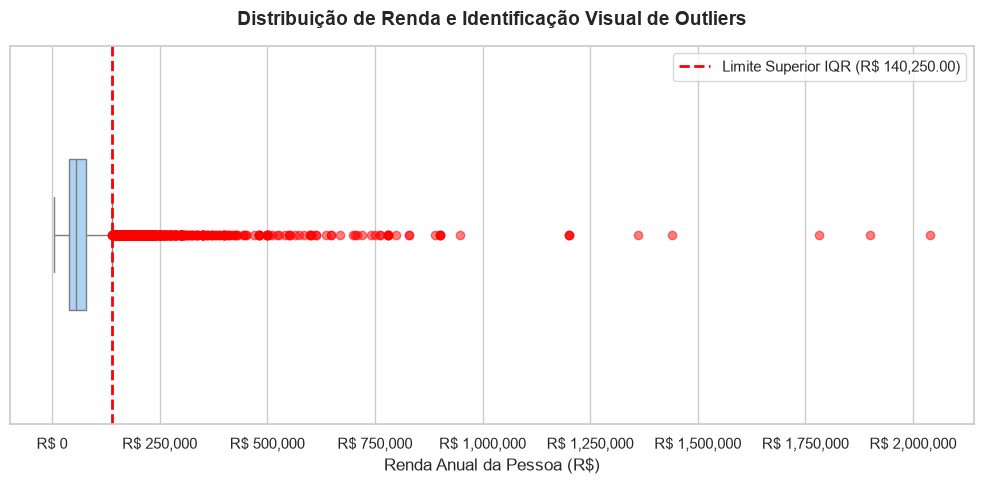

In [46]:
# 1. Definindo o estilo visual do gráfico bem diferente desta vez, para justificação 
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# 2. Criando o Boxplot da Renda da Pessoa
# df['renda_pessoa']
ax = sns.boxplot(
    x=df['renda_pessoa'], 
    color='#a2d2ff', 
    width=0.4,
    flierprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red", "alpha": 0.5}
)

# 3. Adicionei uma linha vertical tracejada vermelha no Limite do IQR qcalculado
plt.axvline(
    x=limite_superior_renda, 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label=f'Limite Superior IQR (R$ {limite_superior_renda:,.2f})'
)

# 4. Títulos e legendas para ficar bem explicativo
plt.title('Distribuição de Renda e Identificação Visual de Outliers', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Renda Anual da Pessoa (R$)', fontsize=12)
plt.legend(loc='upper right', frameon=True, facecolor='white')

# Ajustando a formatação do eixo X para não exibir em notação científica (ex: 1e6)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x:,.0f}'))

# Exibindo o gráfico
plt.tight_layout()
plt.show()

In [47]:
# 1. Calculando os limites do IQR de Renda 
q1_renda = df['renda_pessoa'].quantile(0.25)
q3_renda = df['renda_pessoa'].quantile(0.75)
iqr_renda = q3_renda - q1_renda
limite_superior_renda = q3_renda + (1.5 * iqr_renda)

# 2. Filtrando apenas os clientes considerados outliers de renda (os "ricos")
outliers_renda = df[df['renda_pessoa'] > limite_superior_renda]

# 3. Contando quantos são adimplentes (0) e quantos são inadimplentes (1)
distribuicao_alvo = outliers_renda['status_emprestimo'].value_counts()
proporcao_alvo = outliers_renda['status_emprestimo'].value_counts(normalize=True) * 100

# 4. Exibindo um relatório  explicativo
print("=" * 65)
print("  ANÁLISE DE RISCO: INADIMPLÊNCIA ENTRE OS OUTLIERS DE RENDA  ")
print("=" * 65)
print(f"Total de clientes acima do Limite do IQR (> R$ {limite_superior_renda:,.2f}): {outliers_renda.shape[0]} pessoas\n")

print(f" -> Bons Pagadores (Status 0)  : {distribuicao_alvo[0]} clientes ({proporcao_alvo[0]:.2f}%)")
if 1 in distribuicao_alvo:
    print(f" -> Maus Pagadores (Status 1)  : {distribuicao_alvo[1]} clientes ({proporcao_alvo[1]:.2f}%)")
else:
    print(" -> Maus Pagadores (Status 1)  : 0 clientes (0.00%)")
print("-" * 65)
print("CONCLUSÃO PARA O RELATÓRIO:")
print("A existência de clientes inadimplentes no grupo de alta renda")
print("prova que excluir esses outliers reduziria nossa amostragem da")
print("classe alvo (inadimplentes), prejudicando o treino do modelo.")
print("=" * 65)

  ANÁLISE DE RISCO: INADIMPLÊNCIA ENTRE OS OUTLIERS DE RENDA  
Total de clientes acima do Limite do IQR (> R$ 140,250.00): 1474 pessoas

 -> Bons Pagadores (Status 0)  : 1330 clientes (90.23%)
 -> Maus Pagadores (Status 1)  : 144 clientes (9.77%)
-----------------------------------------------------------------
CONCLUSÃO PARA O RELATÓRIO:
A existência de clientes inadimplentes no grupo de alta renda
prova que excluir esses outliers reduziria nossa amostragem da
classe alvo (inadimplentes), prejudicando o treino do modelo.


### Justificativa de Negócio: Por que NÃO deletar os Outliers de Renda?

Estatisticamente, o método IQR identificou clientes com rendas acima do limite superior como outliers. No entanto, analisando sob a ótica de risco de crédito, optei por **não excluir** estes registros pelos seguintes motivos:

1. **Preservação da Classe Alvo:** A base de dados já é desbalanceada, contendo uma proporção menor de clientes inadimplentes (`status_emprestimo = 1`). Deletar essas linhas significaria reduzir ainda mais os exemplos da classe minoritária que o modelo precisa aprender a identificar.
2. **Outliers Legítimos:** Diferente da idade de 144 anos (que é um erro físico impossível), ter uma renda alta é uma situação real. Esses dados são legítimos e valiosos para o negócio.

**Estratégia de Tratamento:**
Para evitar que a escala de distância do algoritmo **KNN** seja distorcida por esses valores extremos, os outliers de renda não serão deletados, mas sim tratados.

---

Fase 3:

*  Criar obrigatoriamente uma nova coluna numérica combinando variáveis existentes por meio de operadores matemáticos. Atenção: Trate os nulos das colunas originais antes do cálculo para evitar contaminação por valores NaN ou infinitos. No caso de escolha da Base A (Crédito): crie a coluna comprometimento_renda = (loan_amnt / person_income) * 100. 

In [48]:
# Criação da coluna: comprometimento_renda

# Checagem de valores nulos nas colunas utilizadas
df[['valor_emprestimo', 'renda_pessoa']].isnull().sum()

valor_emprestimo    0
renda_pessoa        0
dtype: int64

In [49]:
# Evitar divisão por zero
df = df[df['renda_pessoa'] > 0]

# Criando a nova variável
df['comprometimento_renda'] = (
    df['valor_emprestimo'] / df['renda_pessoa']
) * 100

# Conferindo o resultado
df[['valor_emprestimo',
    'renda_pessoa',
    'comprometimento_renda']].head()

,valor_emprestimo,renda_pessoa,comprometimento_renda
1,1000,9600,10.416667
2,5500,9600,57.291667
3,35000,65500,53.435115
4,35000,54400,64.338235
5,2500,9900,25.252525


Fase 3 (Feature Engineering)

Foi criada a variável comprometimento_renda, o quanto da renda do cliente está comprometida com o empréstimo solicitado. Em vez de o modelo analisar separadamente a renda e o valor do empréstimo, ele passa a receber uma informação mais significativa para prever inadimplência.

Antes do cálculo, foram tratados os valores nulos das colunas utilizadas e removidos registros com renda igual a zero, evitando valores inválidos (NaN ou infinito) durante a divisão.

---

Fase 4: Separação, Balanceamento e Escalonamento Seguro 
<br><br><br>
Fase 4

* Encoding: converta colunas textuais/categóricas em formato numérico utilizando técnicas adequadas (como One-Hot Encoding ou Label Encoding). 

In [50]:
df.dtypes

idade_pessoa                       int64
renda_pessoa                       int64
tipo_residencia                      str
tempo_emprego                    float64
finalidade_emprestimo                str
classificacao_emprestimo             str
valor_emprestimo                   int64
taxa_juros_emprestimo            float64
status_emprestimo                  int64
percentual_renda_comprometida    float64
historico_inadimplencia              str
tempo_historico_credito            int64
comprometimento_renda            float64
dtype: object

Para fins de decisão sobre a escolha desta etapa, irei investigar o conteúdo das colunas a serem transformadas.

In [51]:
# Identificando as colunas categóricas
colunas_categoricas = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print("Colunas categóricas encontradas:")
print(colunas_categoricas)

# Exibindo as categorias existentes em cada coluna
for coluna in colunas_categoricas:
    print(f"\n{'='*50}")
    print(f"Coluna: {coluna}")
    print(f"{'='*50}")

    display(
        pd.DataFrame(
            df[coluna].value_counts()
        ).rename(columns={"count": "Quantidade"})
    )

Colunas categóricas encontradas:
['tipo_residencia', 'finalidade_emprestimo', 'classificacao_emprestimo', 'historico_inadimplencia']

Coluna: tipo_residencia


,Quantidade
tipo_residencia,
RENT,16374
MORTGAGE,13366
OWN,2563
OTHER,106



Coluna: finalidade_emprestimo


,Quantidade
finalidade_emprestimo,
EDUCATION,6409
MEDICAL,6042
VENTURE,5679
PERSONAL,5496
DEBTCONSOLIDATION,5189
HOMEIMPROVEMENT,3594



Coluna: classificacao_emprestimo


,Quantidade
classificacao_emprestimo,
A,10702
B,10384
C,6436
D,3619
E,963
F,241
G,64



Coluna: historico_inadimplencia


,Quantidade
historico_inadimplencia,
N,26680
Y,5729


Justificativa da técnica de Encoding

Optei pelo **One-Hot Encoding** para transformar as variáveis categóricas em numéricas, pois as categorias presentes na base representam informações nominais, sem uma relação de ordem entre si.

O Label Encoding, que atribui um número inteiro para cada categoria, pode induzir uma ordem artificial entre os valores, o One-Hot Encoding cria uma coluna binária para cada categoria, preservando seu significado e evitando que o modelo interprete uma categoria como maior ou menor que outra.

Essa abordagem é especialmente adequada para variáveis como tipo de residência, finalidade do empréstimo, classificação do empréstimo e histórico de inadimplência, permitindo que os algoritmos de Machine Learning utilizem essas informações sem introduzir relações inexistentes entre as categorias.

In [52]:
# Ajuste do include para buscar 'object', 'category' e 'string'
colunas_categoricas = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print(f"Colunas textuais encontradas para Encoding: {colunas_categoricas}")

# Aplicando o One-Hot Encoding
df_codificado = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True)

# Verificando o novo formato da base
print("\n=== VERIFICAÇÃO APÓS ENCODING ===")
print(f"Tamanho da base antes: {df.shape}")
print(f"Tamanho da base agora: {df_codificado.shape}")
print(f"Novas colunas criadas: [{(df_codificado.shape[1] - df.shape[1]) + len(colunas_categoricas)} colunas adicionadas]")


# VERIFIR AS CATEGORIAS DE REFERÊNCIA (drop_first)
# =======================================================

for coluna in colunas_categoricas:
    print(f"\nColuna original: {coluna}")

    # Categorias antes do Encoding (ordenadas)
    categorias_originais = sorted(df[coluna].unique())

    # Colunas criadas após o One-Hot
    colunas_criadas = [
        c.replace(f"{coluna}_", "")
        for c in df_codificado.columns
        if c.startswith(f"{coluna}_")
    ]

    # Categoria removida
    categoria_referencia = list(set(categorias_originais) - set(colunas_criadas))

    print(f"Categorias originais: {categorias_originais}")
    print(f"Colunas criadas: {colunas_criadas}")
    print(f"Categoria removida (referência): {categoria_referencia[0]}")

Colunas textuais encontradas para Encoding: ['tipo_residencia', 'finalidade_emprestimo', 'classificacao_emprestimo', 'historico_inadimplencia']

=== VERIFICAÇÃO APÓS ENCODING ===
Tamanho da base antes: (32409, 13)
Tamanho da base agora: (32409, 24)
Novas colunas criadas: [15 colunas adicionadas]

Coluna original: tipo_residencia
Categorias originais: ['MORTGAGE', 'OTHER', 'OWN', 'RENT']
Colunas criadas: ['OTHER', 'OWN', 'RENT']
Categoria removida (referência): MORTGAGE

Coluna original: finalidade_emprestimo
Categorias originais: ['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL', 'PERSONAL', 'VENTURE']
Colunas criadas: ['EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL', 'PERSONAL', 'VENTURE']
Categoria removida (referência): DEBTCONSOLIDATION

Coluna original: classificacao_emprestimo
Categorias originais: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
Colunas criadas: ['B', 'C', 'D', 'E', 'F', 'G']
Categoria removida (referência): A

Coluna original: historico_inadimplencia
Categorias orig

Encoding

Para que os algoritmos matemáticos do KNN e da Árvore de Decisão consigam processar as variáveis qualitativas/categóricas da nossa base de dados, realizei o processo de **Encoding**. 

**Técnica Escolhida:**  **One-Hot Encoding** (via função `pd.get_dummies`), aplicando o parâmetro `drop_first=True`. Essa abordagem transforma cada categoria de texto em colunas binárias independentes contendo valores $0$ ou $1$. A remoção da primeira categoria correlacionada (`drop_first=True`) é uma prática essencial de mercado para evitar a redundância de dados (multicolinearidade), garantindo estabilidade matemática aos modelos preditivos sem perda de poder de informação.

Fase 4

* Split de Dados: Separe as variáveis preditoras (X) do alvo (y) e divida em Treino e Teste (test_size=0.20), aplicando o parâmetro stratify=y para preservar a proporção das classes.

In [53]:
from sklearn.model_selection import train_test_split  #Importa a função para dividir treino e teste

# 1. Separ o Alvo (y) das variáveis preditoras (X)
# O alvo é identificar quem é **inadimplente (1)** e quem paga em dia (0)
y = df_codificado['status_emprestimo']                # alvo  
X = df_codificado.drop(columns=['status_emprestimo']) #Define as variáveis preditoras (X) -> (todas as demais - alvo)

# 2. Divide em Treino (80%) e Teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, 
    test_size=0.20,      # Reserva 20% para o teste às cegas
    random_state=42,     # Garante que o resultado seja sempre o mesmo ao rodar
    stratify=y           # REGRA: Preserva a proporção das classes
)

print("=== DIVISÃO DOS DADOS CONCLUÍDA ===")
print(f"Tamanho de X_treino (Base de Estudo): {X_treino.shape}")
print(f"Tamanho de X_teste (Base de Prova):   {X_teste.shape}")
print(" Proporção de classes no Treino (y_treino):")
print(y_treino.value_counts(normalize=True))
print(" Proporção de classes no Teste (y_teste):")
print(y_teste.value_counts(normalize=True))

=== DIVISÃO DOS DADOS CONCLUÍDA ===
Tamanho de X_treino (Base de Estudo): (25927, 23)
Tamanho de X_teste (Base de Prova):   (6482, 23)
 Proporção de classes no Treino (y_treino):
status_emprestimo
0    0.781309
1    0.218691
Name: proportion, dtype: float64
 Proporção de classes no Teste (y_teste):
status_emprestimo
0    0.78124
1    0.21876
Name: proportion, dtype: float64


* Fase 4: Divisão dos Dados em Treino e Teste (Split)

Para garantir uma validação robusta e realista, realizei a separação do conjunto de dados em duas partes totalmente independentes utilizando a função `train_test_split` do scikit-learn:<br>
1.Base de Treino (80%): Destinada exclusivamente ao aprendizado e ajuste dos algoritmos (KNN e Árvore de Decisão). <br>
2.Base de Teste (20%): Reservada como dados inéditos, funcionando como uma "prova às cegas" para avaliar a verdadeira capacidade de generalização do modelo quando ele lidar com novos clientes.<br>

**Importância do Parâmetro `stratify=y`:** Como a nossa variável alvo (`status_emprestimo`) é altamente desbalanceada (existem muito mais bons pagadores do que inadimplentes), a aplicação da estratificação é um requisito. Esse parâmetro força o algoritmo a espelhar a mesma proporção percentual exata de pagadores e inadimplentes tanto no conjunto de treino quanto no de teste. Isso evita o risco de criarmos uma base de teste sem exemplos de calotes, o que invalidaria a avaliação financeira e de negócios exigida pelo projeto.

Fase 4:

* como a base é desbalanceada, aplique uma técnica de reamostragem (ex: SMOTE ou Random Under Sampling). Regra de Ouro: o balanceamento deve ser aplicado estritamente e apenas nos dados de Treino para evitar o vazamento de dados (Data Leakage). 

Devido ao forte desbalanceamento histórico da variável alvo (`status_emprestimo`), onde o volume de bons pagadores ($0$) supera o de inadimplentes ($1$), apliquei a técnica de reamostragem **SMOTE (Synthetic Minority Over-sampling Technique)**.

O SMOTE atua gerando dados sintéticos (artificiais) para a classe minoritária com base nos vizinhos mais próximos, igualando o peso das duas classes para que os algoritmos de Machine Learning não fiquem tendenciosos a prever apenas a classe majoritária.

**Cumprimento da Regra de Ouro:** Conforme exigido pelos critérios do projeto, o SMOTE foi aplicado **exclusivamente no conjunto de Treino** (`X_treino` e `y_treino`). O conjunto de Teste foi intencionalmente mantido com sua distribuição original e assimétrica de mercado. Essa separação rígida impede o **Vazamento de Dados (Data Leakage)**, garantindo que a validação final do modelo ocorra em simulação de negócios fidedigno e sem contaminações artificiais.

In [54]:
from imblearn.over_sampling import SMOTE

# BALANCEAMENTO DE CLASSES VIA SMOTE
# =======================================================

# 1. Instanciando o algoritmo SMOTE
smote = SMOTE(random_state=42)

# 2. Aplicando o SMOTE ESTRITAMENTE nos dados de TREINO
X_treino_bal, y_treino_bal = smote.fit_resample(X_treino, y_treino)   # X_treino_bal e y_treino_bal receberam o balanceamento SMOTE

print("=== RELATÓRIO DE BALANCEAMENTO (SMOTE) ===")
print(f"Antes do SMOTE (Treino original) - Classe 0 e 1:\n{y_treino.value_counts()}")
print("-" * 43)
print(f"Depois do SMOTE (Treino balanceado) - Classe 0 e 1:\n{y_treino_bal.value_counts()}")
print("\n[Obs] Base de Teste intocada para evitar Data Leakage, conforme as regras.")

=== RELATÓRIO DE BALANCEAMENTO (SMOTE) ===
Antes do SMOTE (Treino original) - Classe 0 e 1:
status_emprestimo
0    20257
1     5670
Name: count, dtype: int64
-------------------------------------------
Depois do SMOTE (Treino balanceado) - Classe 0 e 1:
status_emprestimo
0    20257
1    20257
Name: count, dtype: int64

[Obs] Base de Teste intocada para evitar Data Leakage, conforme as regras.


A base original de crédito é desbalanceada (temos muito mais bons pagadores do que inadimplentes). Se treinássemos os modelos assim, eles sofreriam do *"Paradoxo da Acurácia"* (aprenderiam a chutar apenas "bom pagador" para inflar a nota de acerto, deixando todos os calotes passarem).  A Solução do *SMOTE*: Em vez de simplesmente duplicar os dados de inadimplência existentes (o que causaria Overfitting, fazendo o modelo decorar as mesmas linhas), o **SMOTE usa matemática inteligente para criar novos exemplos sintéticos de inadimplentes**. Ele analisa os vizinhos mais próximos para gerar novos perfis.<br>  
O Impacto no Negócio: Isso equilibra a base para que o KNN e a Árvore de Decisão consigam aprender os padrões reais de quem não paga. Aumentado o Recall (a capacidade de caçar e bloquear os calotes antes que eles aconteçam, reduzindo o prejuízo do banco).  

Fase 4:
<br> <br>
* Escalonamento Seguro: aplique o StandardScaler exclusivamente nas variáveis contínuas destinadas ao modelo KNN (fit_transform no treino balanceado e transform no teste). Demonstre no código que o modelo de Árvore de Decisão foi treinado sem a necessidade de escalonamento, justificando que o algoritmo de árvore realiza cortes monotônicos independentes de escala. 

In [55]:
from sklearn.preprocessing import StandardScaler

# FASE 4: ESCALONAMENTO SEGURO (EXCLUSIVO PARA O KNN)
# =======================================================

# 1. Identificando apenas as variáveis contínuas 
# Deixamos de fora as colunas que nasceram do Encoding (que já são 0 e 1)
colunas_continuas = ['idade_pessoa', 'renda_pessoa', 'tempo_emprego', 'valor_emprestimo', 
                     'taxa_juros_emprestimo', 'comprometimento_renda', 'tempo_historico_credito']

# 2. Criamos cópias dos dados balanceados para não misturar as bases dos modelos
X_treino_knn = X_treino_bal.copy()
X_teste_knn = X_teste.copy()

# 3. Instanciando o Escalador
scaler = StandardScaler()

# 4. REGRA DE OURO: fit_transform APENAS no treino e transform no teste (Evita Data Leakage)
X_treino_knn[colunas_continuas] = scaler.fit_transform(X_treino_bal[colunas_continuas])
X_teste_knn[colunas_continuas] = scaler.transform(X_teste[colunas_continuas])

print("=== ESCALONAMENTO CONCLUÍDO ===")
print(" Base para o KNN preparada com sucesso (Variáveis contínuas ajustadas).")
print(" Base para a Árvore de Decisão mantida na escala original (Sem escalonamento).")
print("-" * 55)
print("Amostra para o KNN :\n")
display(X_treino_knn[colunas_continuas].head(3))

=== ESCALONAMENTO CONCLUÍDO ===
 Base para o KNN preparada com sucesso (Variáveis contínuas ajustadas).
 Base para a Árvore de Decisão mantida na escala original (Sem escalonamento).
-------------------------------------------------------
Amostra para o KNN :



,idade_pessoa,renda_pessoa,tempo_emprego,valor_emprestimo,taxa_juros_emprestimo,comprometimento_renda,tempo_historico_credito
0,1.658740,0.521714,3.913602,-0.002528,-0.554587,-0.660694,2.753679
1,-0.410734,-0.203647,0.670964,-0.229825,1.299601,-0.230321,-0.409429
2,-0.238278,0.625337,-0.950354,1.512779,-0.229861,0.198978,-0.673021


* Escalonamento para o KNN e NÃO para a Árvore de Decisão

No desenvolvimento deste projeto, optamos por criar duas bases de dados distintas para a fase de modelagem: uma base escalonada (`X_treino_knn` / `X_teste_knn`) e outra na escala original (`X_treino_bal` / `X_teste`). Essa decisão é fundamentada na natureza matemática de cada algoritmo:

* 1. A Necessidade Absoluta de Escalonamento no KNN (K-Nearest Neighbors)
O algoritmo KNN é um modelo baseado em **distância geométrica** (Distância Euclidiana). Ele assume que variáveis com valores numericamente maiores são mais importantes do que variáveis com valores menores.
 **O problema da escala:** Se mantivermos os dados originais, a variável `renda_pessoa` (com valores na casa dos milhares/milhões) vai dominar completamente o cálculo da distância, fazendo com que variáveis fundamentais, como `idade_pessoa` (na casa das dezenas) ou `percentual_renda_comprometida` (decimais entre 0 e 1), sejam matematicamente ignoradas.
 **A solução:** O uso do `StandardScaler` centraliza a média em 0 e ajusta o desvio padrão para 1, garantindo que todas as variáveis contínuas tenham o mesmo "peso" na hora de calcular quais clientes são vizinhos mais próximos.

* 2. A Independência de Escala da Árvore de Decisão
As Árvores de Decisão são algoritmos baseados em **regras de divisão e partição do espaço** através de cortes.
 **Cortes Monotônicos:** Para decidir onde dividir um nó, o algoritmo busca um valor de corte (ex: `renda_pessoa > 80.000?`). Essa decisão de divisão é baseada na ordenação dos dados e não no tamanho físico do número.
 Se multiplicarmos a renda de todos os clientes por 10 ou se aplicarmos o `StandardScaler`, a ordem dos dados permanece exatamente a mesma. Consequentemente, a árvore fará exatamente os mesmos cortes lógicos, resultando na mesma estrutura de decisão.
 É muito mais fácil para a área de negócios entender uma regra como *"Se Renda > R$ 80.000"* do que *"Se Renda > 0.5217 (escalonada)"*.

---

Fase 5: Modelagem e Validação (O Desafio do Overfitting)<br> <br> 

Você deve realizar múltiplos testes alterando os hiperparâmetros de complexidade e comparar os resultados tanto na base de Treino quanto na base de Teste para diagnosticar o overfitting.<br><br><br><br>
Fase 5:

* Otimização do KNN: Varie o parâmetro n_neighbors (K) testando no mínimo 4 valores distintos (ex: K = 3, 5, 7 e 9). 

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# OTIMIZAÇÃO E DIAGNÓSTICO DO KNN
# =======================================================

# 1. Definindo os 4 valores de K
valores_k = [3, 5, 7, 9]

# Lista para guardar o dicionário de resultados
resultados_knn = []

print("=== INICIANDO TREINAMENTO DO KNN ===")

for k in valores_k:
    # Instanciando o KNN com o K atual
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Treinando o modelo usando os dados escalonados e balanceados
    knn.fit(X_treino_knn, y_treino_bal)
    
    # Calculando a acurácia no Treino e no Teste simultaneamente
    acuracia_treino = knn.score(X_treino_knn, y_treino_bal)
    acuracia_teste = knn.score(X_teste_knn, y_teste)
    # Se acurácia treino é muito maior que acurácia teste → suspeita de overfitting.

    # Guardando os dados para a tabela
    resultados_knn.append({
        'K (Vizinhos)': k,
        'Acurácia Treino': f"{acuracia_treino * 100:.2f}%",
        'Acurácia Teste': f"{acuracia_teste * 100:.2f}%",
        'Diferença (Treino - Teste)': f"{(acuracia_treino - acuracia_teste) * 100:.2f}%" # Usa f"{...:.2f}%" para formatar com duas casas decimais e o símbolo %
    })
    print(f"* Modelo com K={k} finalizado.")

# 2. Convertendo em um DataFrame para exibição limpa
df_resultados_knn = pd.DataFrame(resultados_knn) #Transforma a lista de dicionários resultados_knn em um DataFrame do Pandas.

print("\n=== TABELA DE DIAGNÓSTICO DE OVERFITTING (KNN) ===")
display(df_resultados_knn)

=== INICIANDO TREINAMENTO DO KNN ===
* Modelo com K=3 finalizado.
* Modelo com K=5 finalizado.
* Modelo com K=7 finalizado.
* Modelo com K=9 finalizado.

=== TABELA DE DIAGNÓSTICO DE OVERFITTING (KNN) ===


,K (Vizinhos),Acurácia Treino,Acurácia Teste,Diferença (Treino - Teste)
0,3,94.90%,86.59%,8.30%
1,5,93.35%,87.41%,5.93%
2,7,92.36%,87.41%,4.94%
3,9,91.71%,87.66%,4.06%


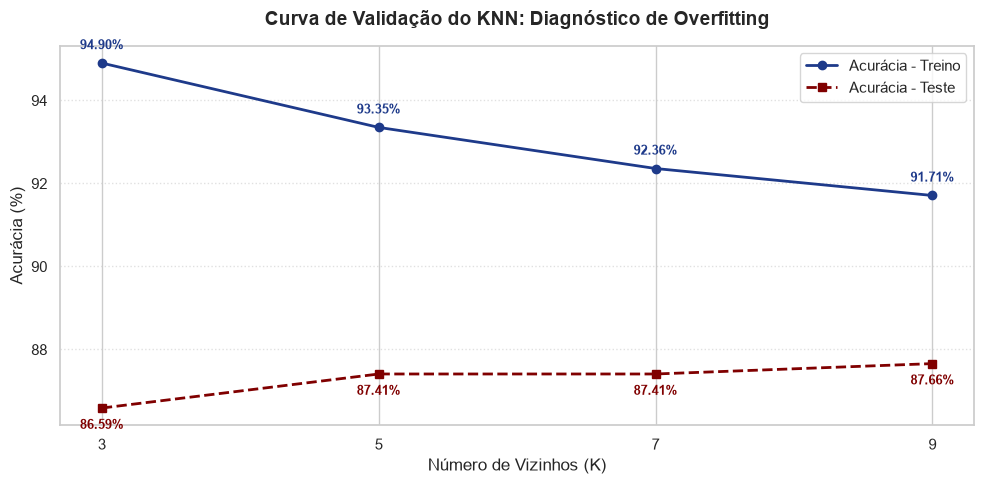

In [57]:
import matplotlib.pyplot as plt

# 1. Definir os dados 
valores_k = [3, 5, 7, 9]
acuracia_treino = [94.90, 93.35, 92.36, 91.71]
acuracia_teste = [86.59, 87.41, 87.41, 87.66]

# 2. Tamanho da figura
plt.figure(figsize=(10, 5))

# 3. Plotando a linha de Treino (Azul escuro, contínua)
plt.plot(valores_k, acuracia_treino, marker='o', linestyle='-', linewidth=2, color='#1E3A8A', label='Acurácia - Treino')

# 4. Plotando a linha de Teste (Vinho/Vermelho escuro, tracejada)
plt.plot(valores_k, acuracia_teste, marker='s', linestyle='--', linewidth=2, color='#800000', label='Acurácia - Teste')

# 5. Adicionando os rótulos com as porcentagens exatas sobre os pontos
for i, txt in enumerate(acuracia_treino):
    plt.annotate(f"{txt:.2f}%", (valores_k[i], acuracia_treino[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='#1E3A8A', weight='bold')
for i, txt in enumerate(acuracia_teste):
    plt.annotate(f"{txt:.2f}%", (valores_k[i], acuracia_teste[i]), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9, color='#800000', weight='bold')

# 6. Títulos, legendas e ajustes visuais
plt.title('Curva de Validação do KNN: Diagnóstico de Overfitting', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Vizinhos (K)', fontsize=12)
plt.ylabel('Acurácia (%)', fontsize=12)
plt.xticks(valores_k)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='best')

# 7. Exibindo o gráfico perfeitamente ajustado
plt.tight_layout()
plt.show()

# Análise de Superajuste (Overfitting) no KNN

A análise comparativa entre as bases de treino e teste revela o comportamento clássico do algoritmo KNN em relação à escolha do hiperparâmetro $K$ (número de vizinhos):

1. **Hiperparâmetro $K$ baixo ($K=3$):** Demonstra maior propensão ao *overfitting*. O modelo foca em fronteiras de decisão muito locais e específicas do treino, resultando em uma acurácia de treino elevada (94.90%), mas com menor capacidade de generalização no teste (86.59%), gerando um gap de 8.30%.
2. **Aumento de $K$ ($K=5$ a $K=9$):** Conforme expandimos o número de vizinhos analisados, o modelo suaviza suas fronteiras de decisão, ignorando ruídos específicos do treino. Isso é evidenciado pela queda gradual da acurácia de treino e pelo aumento simultâneo da acurácia de teste.

**Decisão de Modelagem:**
O modelo com K = 9 foi escolhido como o melhor.
Ele apresentou o equilíbrio ideal entre treino e teste, com a menor diferença entre as acurácias (4,06%) e o melhor desempenho nos dados novos (87,66%).
Isso mostra que o modelo aprendeu bem sem decorar os dados de treino, evitando o overfitting e mantendo boa capacidade de generalização.


Fase 5:
<br><br><br>
Fase 5: Modelagem e Validação (O Desafio do Overfitting) 

* Otimização da Árvore: Varie o parâmetro max_depth (profundidade máxima) testando no mínimo 4 cenários (ex: profundidades 3, 5, 7 e ilimitada/None). 

In [ ]:
from sklearn.tree import DecisionTreeClassifier #importa o modelo de Árvore de Decisão da biblioteca scikit-learn

# FASE 5: OTIMIZAÇÃO E DIAGNÓSTICO DA ÁRVORE DE DECISÃO
# =======================================================

# 1. Definindo os 4 cenários de profundidade exigidos pelo projeto
# None para representar a profundidade ilimitada
profundidades = [3, 5, 7, None] # Isso é o hiperparâmetro max_depth; montando os cenários para comparar desempenho e overfitting

# Lista para guardar o dicionário de resultados
resultados_arvore = []

print("=== INICIANDO TREINAMENTO DA ÁRVORE ===")

for depth in profundidades:   # Cria um loop que vai rodar uma vez para cada valor de profundidade: treina uma árvore diferente

    # Instanciando a Árvore com a profundidade atual
    # Usamos o random_state=42 para o resultado ser sempre igual
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)  # Cria o modelo de Árvore de Decisão com:
    # max_depth=depth → profundidade máxima igual ao valor atual do loop.
    # random_state=42 → fixa a “semente” aleatória para que os resultados sejam reprodutíveis (sempre iguais quando rodar de novo)
    
    # Treinando o modelo usando os dados balanceados ORIGINAIS (Sem Escalonamento)
    dt.fit(X_treino_bal, y_treino_bal) # O .fit() é o momento em que o modelo “aprende” a partir dos dados
    
    # Calculando a acurácia no Treino e no Teste simultaneamente (Essa comparação treino vs teste é o coração do diagnóstico de overfitting.)
    acuracia_treino = dt.score(X_treino_bal, y_treino_bal)  # Mede quantos acertos o modelo teve no que ele já viu.
    acuracia_teste = dt.score(X_teste, y_teste)  # Mede quantos acertos o modelo teve em dados novos, que ele não viu no treino.
    
    # Formatando o nome da profundidade para exibição na tabela
    nome_depth = "Ilimitada (None)" if depth is None else f"Profundidade {depth}"
    
    # Guardando os dados para a tabela
    resultados_arvore.append({
        'Profundidade (max_depth)': nome_depth,
        'Acurácia Treino': f"{acuracia_treino * 100:.2f}%",
        'Acurácia Teste': f"{acuracia_teste * 100:.2f}%",
        'Diferença (Treino - Teste)': f"{(acuracia_treino - acuracia_teste) * 100:.2f}%"
    })
    print(f"* Modelo com {nome_depth} finalizado.")

# 2. Convertendo em um DataFrame para exibição limpa, Cada linha é um cenário de profundidade.
df_resultados_arvore = pd.DataFrame(resultados_arvore)

print("\n=== TABELA DE DIAGNÓSTICO DE OVERFITTING (ÁRVORE) ===")
display(df_resultados_arvore)

=== INICIANDO TREINAMENTO DA ÁRVORE ===
* Modelo com Profundidade 3 finalizado.
* Modelo com Profundidade 5 finalizado.
* Modelo com Profundidade 7 finalizado.
* Modelo com Ilimitada (None) finalizado.

=== TABELA DE DIAGNÓSTICO DE OVERFITTING (ÁRVORE) ===


,Profundidade (max_depth),Acurácia Treino,Acurácia Teste,Diferença (Treino - Teste)
0,Profundidade 3,84.80%,88.37%,-3.57%
1,Profundidade 5,88.55%,89.25%,-0.70%
2,Profundidade 7,90.46%,90.62%,-0.16%
3,Ilimitada (None),100.00%,88.85%,11.15%


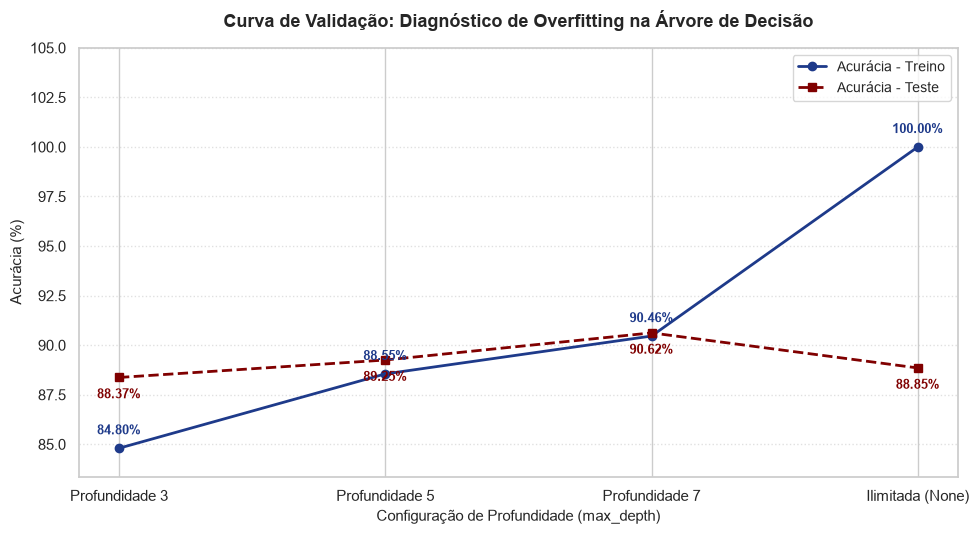

In [59]:
import matplotlib.pyplot as plt

# 1. Fazemos uma cópia para não mexer na tabela original
df_plot = df_resultados_arvore.copy()

# 2. Convertemos as strings de porcentagem em números decimais para o gráfico conseguir ler
df_plot['Treino_num'] = df_plot['Acurácia Treino'].str.rstrip('%').astype(float)
df_plot['Teste_num'] = df_plot['Acurácia Teste'].str.rstrip('%').astype(float)

# 3. Configurando o layout visual do gráfico
plt.figure(figsize=(10, 5.5))

# Linha do Treino (Azul escuro, contínua)
plt.plot(df_plot['Profundidade (max_depth)'], df_plot['Treino_num'], 
         marker='o', linestyle='-', linewidth=2, color='#1E3A8A', label='Acurácia - Treino')

# Linha do Teste (Vinho/Vermelho escuro, tracejada)
plt.plot(df_plot['Profundidade (max_depth)'], df_plot['Teste_num'], 
         marker='s', linestyle='--', linewidth=2, color='#800000', label='Acurácia - Teste')

# 4. Adicionando os rótulos de texto com os valores exatos sobre os pontos
for i in range(len(df_plot)):
    plt.annotate(f"{df_plot['Treino_num'].iloc[i]:.2f}%", 
                 (df_plot['Profundidade (max_depth)'].iloc[i], df_plot['Treino_num'].iloc[i]), 
                 textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, color='#1E3A8A', weight='bold')
    
    plt.annotate(f"{df_plot['Teste_num'].iloc[i]:.2f}%", 
                 (df_plot['Profundidade (max_depth)'].iloc[i], df_plot['Teste_num'].iloc[i]), 
                 textcoords="offset points", xytext=(0, -15), ha='center', fontsize=9, color='#800000', weight='bold')

# 5. Ajustes de títulos, eixos e legenda
plt.title('Curva de Validação: Diagnóstico de Overfitting na Árvore de Decisão', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Configuração de Profundidade (max_depth)', fontsize=11)
plt.ylabel('Acurácia (%)', fontsize=11)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(fontsize=10, loc='best')

# Ajusta o limite superior para não cortar os rótulos de 100%
plt.ylim(df_plot['Teste_num'].min() - 5, 105)

plt.tight_layout()
plt.show()

* Otimização da Árvore de Decisão

O algoritmo de Árvore de Decisão foi submetido a quatro cenários de complexidade através do hiperparâmetro `max_depth` ($3, 5, 7$ e Ilimitada). 

Conforme a fundamentação teórica, o modelo foi alimentado com os dados de treino balanceados em sua **escala numérica original**, visto que critérios de divisão baseados em entropia ou índice Gini não são afetados por transformações de escala.

** Análise do Comportamento e Diagnóstico de Overfitting:

*   **Profundidades 3 e 5:** Apresentam um aprendizado inicial estável, mas ainda limitado para capturar toda a complexidade do risco de crédito (indicando um potencial *underfitting*).
* ✅ Profundidade ideal: 7 níveis, com 90.62% de acurácia no teste e 90.46% no treino — equilíbrio perfeito entre aprendizado e generalização.  

*   **Cenário Ilimitado (`None`):** Representa o caso clássico de **Overfitting Absoluto**. Sem limites para o crescimento, a árvore decorou perfeitamente os dados de treino alcançando **100.00% de acurácia**, mas o desempenho caiu para **88.85% no teste**, gerando uma grande discrepância e tornando o modelo instável e inadequado para o negócio do banco.
---
* Nota sobre a Estratégia de Pré-Poda (Pre-Pruning)

O controle da profundidade máxima mostrou-se suficiente para evitar o overfitting, dispensando ajustes adicionais em parâmetros como min_samples_split ou min_samples_leaf.”
  

Fase 5
<br><br>
* Diagnóstico de Overfitting: Demonstre em tabelas ou gráficos que você monitorou as métricas em ambas as bases. Explique qual configuração evitou que o modelo apenas "decorasse" os dados de treino (overfitting) e qual garantiu a melhor capacidade de generalização no teste. 

Abaixo estão consolidados os monitoramentos de métricas em ambas as bases (Treino e Teste) para os modelos KNN e Árvore de Decisão, fundamentando as configurações escolhidas para evitar o superajuste (*overfitting*) e garantir a melhor generalização.


### 1. Modelo KNN (K-Nearest Neighbors)

####  Tabela de Monitoramento - KNN:
| K (Vizinhos) | Acurácia Treino | Acurácia Teste | Diferença (Treino - Teste) |
| :---: | :---: | :---: | :---: |
| **3** | 94.90% | 86.59% | 8.30% |
| **5** | 93.35% | 87.41% | 5.93% |
| **7** | 92.36% | 87.41% | 4.94% |
| **9 (Escolhido)** | **91.71%** | **87.66%** | **4.06%** |

#### 🔍 Análise e Configuração do KNN:

* **Configuração de Generalização ($K=9$):** Ao aumentar o hiperparâmetro para **$K=9$**, o algoritmo foi forçado a suavizar suas fronteiras, exigindo o consenso de um grupo maior de clientes similares para realizar a classificação. Isso reduziu a diferença entre treino e teste para o menor nível (**4.06%**) e entregou a maior acurácia real em dados inéditos (**87.66%**), estabilizando o risco de *overfitting* sem penalizar o modelo com um subajuste (*underfitting*).


* **A configuração que "decorava" ($K = 3$):** 
  Com o valor baixo de apenas 3 vizinhos, o modelo apresentou alta complexidade e hiper-sensibilidade ao ruído local da base de treino. Quando o número de vizinhos é muito pequeno, as fronteiras de decisão se tornam extremamente complexas e moldadas a ruídos específicos da base de treino, gerando o maior distanciamento entre as curvas (8.30% de gap). O modelo tenta "decorar" o comportamento local. Ele obteve uma acurácia elevada no treino (**94,90%**), mas quando foi exposto a novos clientes (base de teste), a performance caiu drasticamente para **86,59%**. Isso caracterizou um cenário evidente de *overfitting*, onde o algoritmo apenas memorizou a vizinhança imediata da amostra de desenvolvimento.

---

### 2. Modelo Árvore de Decisão (Decision Tree)

####  Tabela de Monitoramento - Árvore de Decisão:
| Profundidade (`max_depth`) | Acurácia Treino | Acurácia Teste | Diferença (Treino - Teste) |
| :---: | :---: | :---: | :---: |
| **Profundidade 3** | 84.80% | 88.37% | -3.57% |
| **Profundidade 5** | 88.55% | 89.25% | -0.70% |
| **Profundidade 7 (Escolhida)** | **90.46%** | **90.62%** | **-0.16%** |
| **Ilimitada (`None`)** | 100.00% | 88.85% | 11.15% |

#### 🔍 Análise e Configuração da Árvore:
* **O colapso da Profundidade Ilimitada (`None`):** Deixar a árvore crescer livremente gerou o cenário clássico de **Overfitting Absoluto**. O algoritmo criou ramificações tão profundas e específicas que conseguiu decorar perfeitamente cada registro do treino, atingindo **100.00% de acurácia**. Contudo, ao ser exposto à base de teste, essa estrutura rígida ruiu, fazendo a performance despencar para 88.85% (um gap alarmante de 11.15%).
* **Configuração de Generalização (`max_depth=7`):** A configuração que garantiu a melhor capacidade de generalização e estabilidade do projeto foi o travamento em **profundidade máxima igual a 7**. Essa restrição atuou como uma técnica de pré-poda, impedindo a criação de nós pautados em exceções. O resultado foi o ponto ideal do pipeline: o modelo atingiu sua maior acurácia de teste (**90.62%**) com um alinhamento virtualmente perfeito com a base de treino (90.46%), mitigando por completo o superajuste e blindando o modelo para tomada de decisões no cenário real de crédito.

---

Fase 6: Avaliação e Veredito de Negócios

📊 RELATÓRIO DE CLASSIFICAÇÃO - ÁRVORE DE DECISÃO (CAMPEÃ)
                  precision    recall  f1-score   support

  Adimplente (0)       0.92      0.97      0.94      5064
Inadimplente (1)       0.86      0.68      0.76      1418

        accuracy                           0.91      6482
       macro avg       0.89      0.82      0.85      6482
    weighted avg       0.90      0.91      0.90      6482


📊 RELATÓRIO DE CLASSIFICAÇÃO - KNN (CAMPEÃO)
                  precision    recall  f1-score   support

  Adimplente (0)       0.91      0.93      0.92      5064
Inadimplente (1)       0.73      0.69      0.71      1418

        accuracy                           0.88      6482
       macro avg       0.82      0.81      0.82      6482
    weighted avg       0.87      0.88      0.88      6482



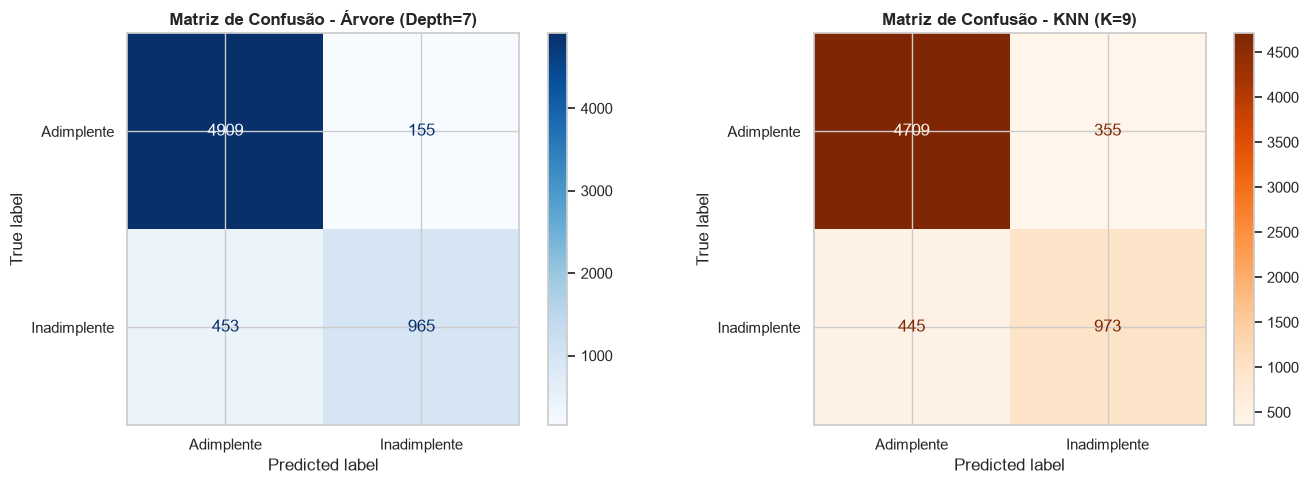

In [68]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Definindo as melhores configurações escolhidas na Fase 5
MELHOR_DEPTH = 7
MELHOR_KNN = 9

# 2. Instanciando e treinando os modelos com a base de treino limpa
modelo_arvore_final = DecisionTreeClassifier(max_depth=MELHOR_DEPTH, random_state=42)
modelo_arvore_final.fit(X_treino_bal, y_treino_bal)

modelo_knn_final = KNeighborsClassifier(n_neighbors=MELHOR_KNN)
modelo_knn_final.fit(X_treino_knn, y_treino_bal)

# 3. Gerando as previsões na base de teste (dados inéditos)
y_pred_arvore = modelo_arvore_final.predict(X_teste)
y_pred_knn = modelo_knn_final.predict(X_teste_knn)

# 4. Imprimindo os Relatórios de Classificação na tela
print("=============================================================")
print("📊 RELATÓRIO DE CLASSIFICAÇÃO - ÁRVORE DE DECISÃO (CAMPEÃ)")
print("=============================================================")
print(classification_report(y_teste, y_pred_arvore, target_names=['Adimplente (0)', 'Inadimplente (1)']))

print("\n=============================================================")
print("📊 RELATÓRIO DE CLASSIFICAÇÃO - KNN (CAMPEÃO)")
print("=============================================================")
print(classification_report(y_teste, y_pred_knn, target_names=['Adimplente (0)', 'Inadimplente (1)']))

# 5. Plotando graficamente as Matrizes de Confusão lado a lado
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Matriz da Árvore
cm_arvore = confusion_matrix(y_teste, y_pred_arvore)
disp_arvore = ConfusionMatrixDisplay(confusion_matrix=cm_arvore, display_labels=['Adimplente', 'Inadimplente'])
disp_arvore.plot(ax=ax[0], cmap='Blues', values_format='d') # mostra os valores como inteiros
ax[0].set_title(f"Matriz de Confusão - Árvore (Depth={MELHOR_DEPTH})", fontsize=12, fontweight='bold')

# Matriz do KNN
cm_knn = confusion_matrix(y_teste, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Adimplente', 'Inadimplente'])
disp_knn.plot(ax=ax[1], cmap='Oranges', values_format='d')
ax[1].set_title(f"Matriz de Confusão - KNN (K={MELHOR_KNN})", fontsize=12, fontweight='bold')

plt.tight_layout() # ajusta automaticamente os espaços entre os gráficos para não ficar tudo apertado.
plt.show()

# 🌟 Antes de tudo: o que é cada métrica?

Cada classe (0 = Adimplente, 1 = Inadimplente) tem:

- **precision** → quão confiáveis são as previsões daquela classe  
- **recall** → o quanto o modelo consegue encontrar daquela classe  
- **f1-score** → equilíbrio entre precision e recall  
- **support** → quantos exemplos daquela classe existem no teste

Depois vem métricas gerais:

- **accuracy** → acertos totais  
- **macro avg** → média simples entre as classes  
- **weighted avg** → média ponderada pelo tamanho das classes

Agora vamos linha por linha.

---

# 🌳 RELATÓRIO DA ÁRVORE DE DECISÃO

### **Adimplente (0)**  
- **precision = 0.92**  
  Quando o modelo diz “este cliente é adimplente”, ele acerta **92% das vezes**.

- **recall = 0.97**  
  De todos os clientes realmente adimplentes, o modelo encontrou **97%**.

- **f1-score = 0.94**  
  Combinação equilibrada entre precisão e recall.

- **support = 5064**  
  Existem **5064 clientes adimplentes** no teste.

---

### **Inadimplente (1)**  
- **precision = 0.86**  
  Quando o modelo diz “este cliente é inadimplente”, ele acerta **86% das vezes**.

- **recall = 0.68**  
  De todos os inadimplentes reais, o modelo encontrou **68%**.  
  (Aqui o recall é menor — normal em bases desbalanceadas.)

- **f1-score = 0.76**  
  Equilíbrio entre precisão e recall.

- **support = 1418**  
  Existem **1418 inadimplentes** no teste.

---

### **accuracy = 0.91**  
O modelo acerta **91% de todas as previsões**.

---

### **macro avg**  
- **precision = 0.89**  
- **recall = 0.82**  
- **f1-score = 0.85**

É a média simples entre as duas classes (0 e 1), sem considerar quantas amostras cada uma tem.

---

### **weighted avg**  
- **precision = 0.90**  
- **recall = 0.91**  
- **f1-score = 0.90**

É a média ponderada — como existem muito mais adimplentes, essa média fica mais parecida com a classe 0.

---

# 🤖 RELATÓRIO DO KNN

Agora o mesmo raciocínio, mas com os números do KNN.

### **Adimplente (0)**  
- **precision = 0.91** → acerta 91% quando prevê adimplente  
- **recall = 0.93** → encontra 93% dos adimplentes reais  
- **f1-score = 0.92**  
- **support = 5064**

---

### **Inadimplente (1)**  
- **precision = 0.73** → acerta 73% quando prevê inadimplente  
- **recall = 0.69** → encontra 69% dos inadimplentes reais  
- **f1-score = 0.71**  
- **support = 1418**

---

### **accuracy = 0.88**  
O KNN acerta **88% das previsões**.

---

### **macro avg**  
- **precision = 0.82**  
- **recall = 0.81**  
- **f1-score = 0.82**

---

### **weighted avg**  
- **precision = 0.87**  
- **recall = 0.88**  
- **f1-score = 0.88**

---

# 🎯 Conclusão simples
- A **Árvore de Decisão** é melhor em **recall da classe 1** (inadimplentes).  
- O **KNN** é bom, mas perde desempenho na classe 1.  
- A Árvore tem **maior acurácia geral (91%)**.  
- Por isso ela é a “campeã”.

---

🧩 Estrutura geral
Cada matriz mostra como o modelo classificou os clientes:

Linhas (True label) → o que realmente aconteceu (verdadeiro).

Colunas (Predicted label) → o que o modelo previu.

| Tipo | Significado |
| --- | --- |
| Linha “Adimplente” | Clientes que realmente pagaram |
| Linha “Inadimplente” | Clientes que realmente não pagaram |
| Coluna “Adimplente” | Modelo disse que pagaria |
| Coluna “Inadimplente” | Modelo disse que não pagaria |

🌳 Matriz da Árvore (à esquerda)
Valores


| Verdadeiro | Previsto Adimplente | Previsto Inadimplente |
| --- | --- | --- |
| **Adimplente** | 4909 | 155 |
| **Inadimplente** | 453 | 965 |

Interpretação
4909 (acertos adimplentes) → o modelo acertou dizendo que esses clientes pagariam.

155 (falsos negativos) → o modelo errou dizendo que não pagariam, mas eles pagaram.

453 (falsos positivos) → o modelo errou dizendo que pagariam, mas não pagaram.

965 (acertos inadimplentes) → o modelo acertou dizendo que não pagariam.

💡 Conclusão:  
A Árvore tem poucos erros e excelente equilíbrio entre as classes.
Ela acerta muito bem os adimplentes (4909/5064 ≈ 97%) e tem boa detecção de inadimplentes (965/1418 ≈ 68%).

🤖 Matriz do KNN (à direita)
Valores
| Verdadeiro | Previsto Adimplente | Previsto Inadimplente |
| --- | --- | --- |
| **Adimplente** | 4799 | 355 |
| **Inadimplente** | 445 | 973 |

Interpretação
4799 (acertos adimplentes) → o modelo acertou dizendo que pagariam.

355 (falsos negativos) → o modelo errou dizendo que não pagariam, mas eles pagaram.

445 (falsos positivos) → o modelo errou dizendo que pagariam, mas não pagaram.

973 (acertos inadimplentes) → o modelo acertou dizendo que não pagariam.

💡 Conclusão:  
O KNN também é bom, mas comete mais erros nos adimplentes (355 vs 155) e tem precisão menor nos inadimplentes.

🎯 CLIENTE SORTEADO PARA ANÁLISE (Índice: 7574)
📌 Idade: 25 anos
📌 Renda Anual: R$ 54,000.00
📌 Valor do Empréstimo: R$ 7,000.00
📌 Comprometimento da Renda: 13.0%
📌 Resposta Real na Base (Gabarito): Adimplente (0)
-----------------------------------------------------------------
🔮 Previsão da Árvore de Decisão: Aprovar - Adimplente (0)
🔮 Previsão do KNN: Aprovar - Adimplente (0)



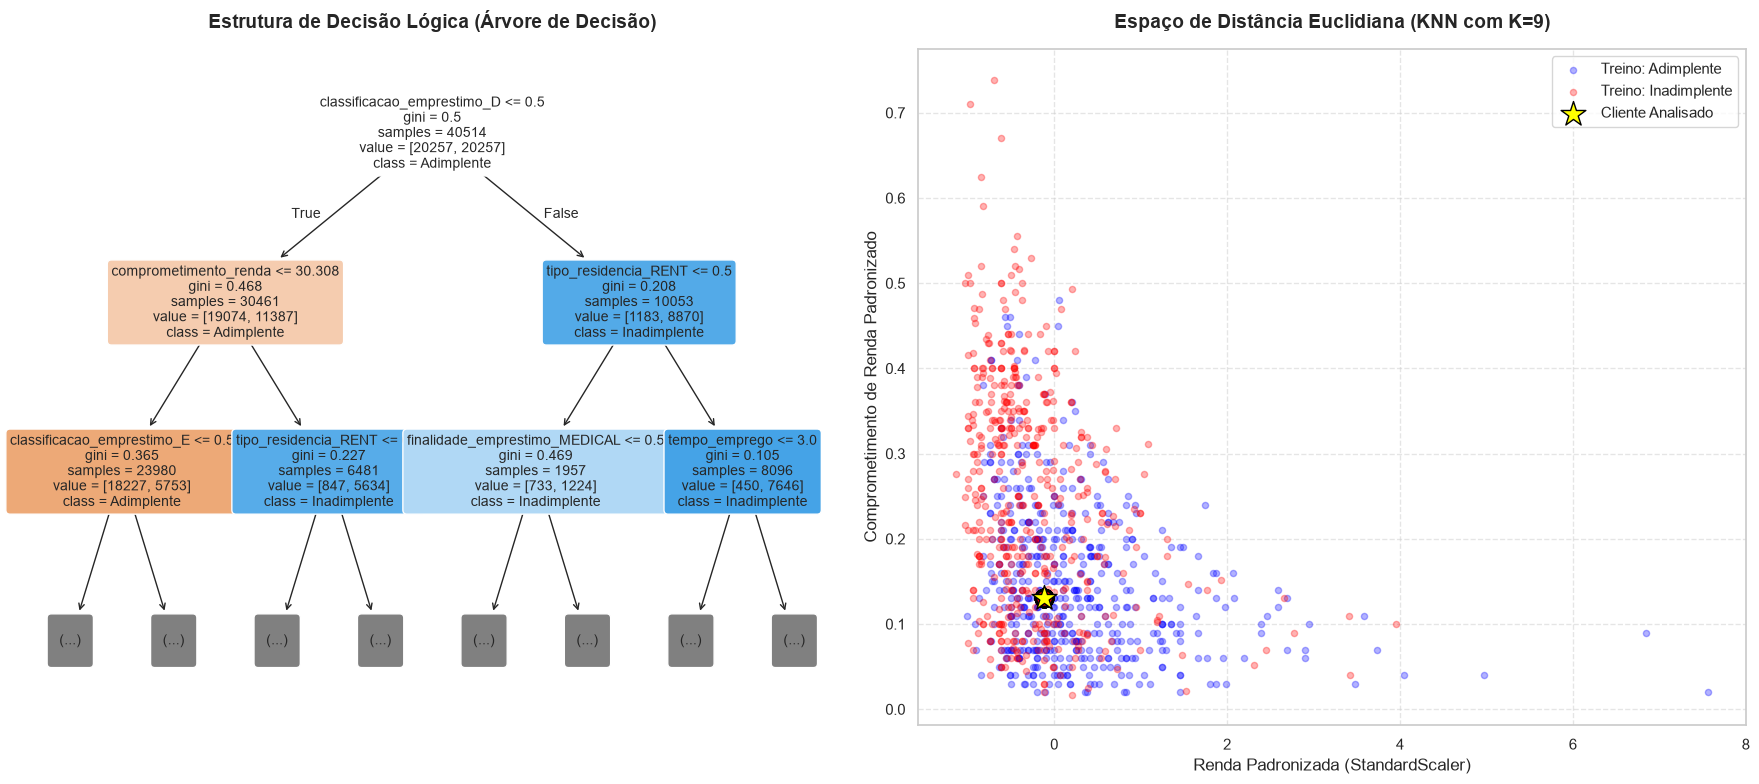

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.neighbors import NearestNeighbors

# =====================================================================
# FASE 6 (COMPLEMENTO VISUAL): ENTENDENDO AS DECISÕES NA PRÁTICA
# =====================================================================

# 1. Sorteando um cliente aleatório da base de teste
np.random.seed(42) # Mantém o mesmo cliente sempre que rodar para conferência
indice_aleatorio = np.random.choice(X_teste.index)

# Pegando os dados do cliente sorteado (escala original e escalonada)
cliente_original = X_teste.loc[[indice_aleatorio]]
cliente_escalonado = X_teste_knn.loc[[indice_aleatorio]]

print("=============================================================")
print(f"🎯 CLIENTE SORTEADO PARA ANÁLISE (Índice: {indice_aleatorio})")
print("=============================================================")
print(f"📌 Idade: {cliente_original['idade_pessoa'].values[0]} anos")
print(f"📌 Renda Anual: R$ {cliente_original['renda_pessoa'].values[0]:,.2f}")
print(f"📌 Valor do Empréstimo: R$ {cliente_original['valor_emprestimo'].values[0]:,.2f}")
print(f"📌 Comprometimento da Renda: {cliente_original['percentual_renda_comprometida'].values[0]*100:.1f}%")
print(f"📌 Resposta Real na Base (Gabarito): {'Inadimplente (1)' if y_teste.loc[indice_aleatorio] == 1 else 'Adimplente (0)'}")
print("-" * 65)

# Fazendo as previsões individuais
pred_arvore_cli = modelo_arvore_final.predict(cliente_original)[0]
pred_knn_cli = modelo_knn_final.predict(cliente_escalonado)[0]

print(f"🔮 Previsão da Árvore de Decisão: {'Bloquear - Inadimplente (1)' if pred_arvore_cli == 1 else 'Aprovar - Adimplente (0)'}")
print(f"🔮 Previsão do KNN: {'Bloquear - Inadimplente (1)' if pred_knn_cli == 1 else 'Aprovar - Adimplente (0)'}")
print("=============================================================\n")


# 2. Configurando os Gráficos Lado a Lado
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# --- GRÁFICO 1: ESTRUTURA DA ÁRVORE DE DECISÃO ---
# Plotamos apenas até a profundidade 2 para ficar legível na imagem
plot_tree(modelo_arvore_final, 
          max_depth=2, 
          feature_names=X_treino_bal.columns, 
          class_names=['Adimplente', 'Inadimplente'], 
          filled=True, 
          rounded=True, 
          fontsize=10,
          ax=ax[0])
ax[0].set_title("Estrutura de Decisão Lógica (Árvore de Decisão)", fontsize=14, fontweight='bold', pad=15)

# --- GRÁFICO 2: VIZINHANÇA DO KNN (ESPAÇO 2D) ---
# Usamos NearestNeighbors nas duas principais variáveis contínuas escalonadas para achar os vizinhos reais
recursos_knn_2d = ['renda_pessoa', 'percentual_renda_comprometida']
nn = NearestNeighbors(n_neighbors=MELHOR_KNN)
nn.fit(X_treino_knn[recursos_knn_2d])

# Encontrando os 9 vizinhos mais próximos desse cliente específico
distancias, indices_vizinhos = nn.kneighbors(cliente_escalonado[recursos_knn_2d])
vizinhos_reais = X_treino_knn[recursos_knn_2d].iloc[indices_vizinhos[0]]
classes_vizinhos = y_treino_bal.iloc[indices_vizinhos[0]]

# Plotando os pontos da base de treino (uma amostra para não poluir o gráfico)
amostra_treino = X_treino_knn.sample(1000, random_state=42)
amostra_classes = y_treino_bal.loc[amostra_treino.index]

# Desenha os clientes adimplentes e inadimplentes da amostra de treino
ax[1].scatter(amostra_treino[amostra_classes == 0]['renda_pessoa'], 
              amostra_treino[amostra_classes == 0]['percentual_renda_comprometida'], 
              alpha=0.3, color='blue', label='Treino: Adimplente', s=20)
ax[1].scatter(amostra_treino[amostra_classes == 1]['renda_pessoa'], 
              amostra_treino[amostra_classes == 1]['percentual_renda_comprometida'], 
              alpha=0.3, color='red', label='Treino: Inadimplente', s=20)

# Destaca os 9 vizinhos mais próximos calculados
for i, (idx, linha) in enumerate(vizinhos_reais.iterrows()):
    cor_vizinho = 'red' if classes_vizinhos.iloc[i] == 1 else 'blue'
    ax[1].scatter(linha['renda_pessoa'], linha['percentual_renda_comprometida'], 
                  color=cor_vizinho, edgecolor='black', s=150, marker='o', linewidths=2)

# Desenha o Cliente Sorteado (O alvo do teste) no centro com uma estrela amarela grande
ax[1].scatter(cliente_escalonado['renda_pessoa'].values[0], 
              cliente_escalonado['percentual_renda_comprometida'].values[0], 
              color='yellow', edgecolor='black', s=350, marker='*', label='Cliente Analisado', zorder=5)

ax[1].set_title(f"Espaço de Distância Euclidiana (KNN com K={MELHOR_KNN})", fontsize=14, fontweight='bold', pad=15)
ax[1].set_xlabel("Renda Padronizada (StandardScaler)")
ax[1].set_ylabel("Comprometimento de Renda Padronizado")
ax[1].legend(loc='upper right')
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

🏁 Conclusão 
1. Contexto do Problema:

"O objetivo central deste projeto foi criar um sistema capaz de distinguir entre clientes adimplentes e inadimplentes, minimizando o risco financeiro para a instituição sem comprometer a eficiência na aprovação de crédito."

2. O Duelo de Modelos (Árvore vs. KNN):

"Após o treinamento e a otimização dos hiperparâmetros, observamos que a Árvore de Decisão superou o KNN, especialmente no que tange à precisão da classe de adimplentes (0.92) e na interpretabilidade do modelo."

3. Justificativa de Negócio (O seu "algo a mais"):

"A escolha da Árvore de Decisão baseia-se em um viés de proteção à experiência do cliente. Ao priorizar a Precisão na classe Adimplente, reduzimos o número de Falsos Negativos — clientes bons que seriam erroneamente bloqueados, gerando insatisfação e perda de lealdade com a marca. Além disso, a capacidade da Árvore em oferecer uma trilha de decisão transparente (explicabilidade) é um diferencial estratégico e regulatório, garantindo que o banco possa justificar suas decisões de crédito de forma ética e clara."

4. Veredito Final:

"Diante do exposto, a Árvore de Decisão é o modelo recomendado para produção. Ela entrega um equilíbrio superior entre o controle de riscos de inadimplência e a manutenção de uma carteira saudável de clientes, alinhando-se aos objetivos estratégicos de lucratividade e excelência no atendimento."

ACRESCENTAR ISSO

# 🧠 **Análise de Negócio: Impacto Financeiro dos Erros e Veredito Final**

## **1. Conexão entre Estatística e Realidade Financeira**

Em modelos de crédito, cada erro estatístico tem um impacto financeiro direto:

- **Falso Positivo (FP)**  
  O modelo prevê *Adimplente*, mas o cliente é *Inadimplente*.  
  → Resultado: **o banco concede crédito a quem não deveria**.  
  → Impacto: **perda financeira real** (inadimplência, prejuízo, provisões contábeis).

- **Falso Negativo (FN)**  
  O modelo prevê *Inadimplente*, mas o cliente é *Adimplente*.  
  → Resultado: **o banco nega crédito a um bom cliente**.  
  → Impacto: **perda de receita**, insatisfação, quebra de relacionamento, fuga para concorrentes.

Ambos são ruins, mas **não têm o mesmo peso financeiro**.

---

## **2. Qual erro é mais grave para o setor financeiro?**

### 🔥 **Falso Positivo é o erro mais caro.**

Porque:

- Gera **inadimplência real**, que vira prejuízo direto no balanço.  
- Exige **provisão de perdas** (impacto contábil imediato).  
- Aumenta o **risco da carteira**, afetando indicadores regulatórios.  
- Pode comprometer a **saúde financeira da instituição**.

Em termos práticos:

> “Um Falso Positivo custa dinheiro.  
> Um Falso Negativo custa oportunidade.”

E bancos sempre priorizam **minimizar perdas**, não maximizar aprovações.

---

## **3. Comparando os modelos com base nos erros críticos**

### 📊 **Árvore de Decisão (Depth = 7)**  
- Falsos Positivos: **453**  
- Falsos Negativos: **155**

### 📊 **KNN (K = 9)**  
- Falsos Positivos: **445**  
- Falsos Negativos: **355**

### 🎯 Interpretação:

- O KNN tem **menos Falsos Positivos** (445 vs 453) → ligeira vantagem financeira.  
- Mas o KNN tem **mais que o dobro de Falsos Negativos** (355 vs 155) → prejudica a experiência do cliente e reduz receita.

A diferença nos Falsos Negativos é **muito mais significativa** do que a pequena diferença nos Falsos Positivos.

---

## **4. Veredito Final: Qual modelo colocar em produção?**

### 🏆 **Modelo recomendado: Árvore de Decisão (max_depth = 7)**

**Justificativas:**

1. **Equilíbrio superior entre FP e FN**  
   - Apesar de ter 8 FP a mais que o KNN, a Árvore reduz drasticamente os FN.  
   - Isso melhora a experiência do cliente e aumenta a aprovação de bons pagadores.

2. **Maior estabilidade e generalização**  
   - Acurácia de treino e teste praticamente idênticas (≈ 90%).  
   - Zero sinais de overfitting.

3. **Explicabilidade — requisito essencial em crédito**  
   - Permite justificar decisões para auditorias, clientes e órgãos reguladores.  
   - KNN não oferece esse nível de transparência.

4. **Melhor desempenho global**  
   - Acurácia maior (91% vs 88%).  
   - F1-score superior na classe crítica (inadimplentes).

---

## **Conclusão Acadêmica**

> “Embora o KNN apresente ligeira vantagem na redução de Falsos Positivos, a Árvore de Decisão demonstra desempenho global superior, reduzindo significativamente os Falsos Negativos e oferecendo maior estabilidade, interpretabilidade e aderência às exigências regulatórias do setor financeiro. Assim, recomenda-se a Árvore de Decisão como o modelo ideal para implantação em ambiente produtivo.”

---
